# Client Mgas/s Performance vs the 75 Mgas/s Anchor

#### Maria Silva, August 2026

We collect per-test throughput (`test_mgas_s`) from benchmarkoor for two
`glamsterdam-devnet-7` suites and check whether every client sustains the
**75 Mgas/s** anchor on **every** test.

| Suite hash | Suite name | Tests |
| --- | --- | --- |
| `9dbe0f5f4ea081b8` | `state-actor-glamsterdam-devnet-7-full-compute` | 2040 |
| `0c5715e398c47aa3` | `state-actor-glamsterdam-devnet-7-full-stateful` | 454 |

**Reading the anchor.** Each benchmark fills a block with a target gas value
(200M or 300M here) and benchmarkoor reports `test_mgas_s = test_gas_used / test_time_ns`.
Because it is a rate, it is directly comparable to the anchor regardless of the
block gas value: a test at 75 Mgas/s means the client would execute a 75M gas
block in exactly 1 second. Anything **below** 75 Mgas/s is a test where the
client is slower than the anchor allows.

**Questions:**
1. Which clients sustain ≥ 75 Mgas/s on all tests, and which do not?
2. For the clients that fall short, which tests/operations are responsible?
3. Are the shortfalls universal (all clients slow on the same test → gas
   schedule issue) or client-specific (→ implementation issue)?

In [1]:
import os
import sys
import json
import math
import warnings
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

In [2]:
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))
src_dir = os.path.join(repo_dir, "src")
sys.path.append(src_dir)

In [3]:
# Credentials for the benchmarkoor API
with open(os.path.join(repo_dir, "secrets.json"), "r") as file:
    secrets_dict = json.load(file)

bearer_token = secrets_dict["benchmarkoor_bearer_token"]

In [4]:
BENCHMARKOOR_BASE_URL = (
    "https://benchmarkoor-api.core.ethpandaops.io/api/v1/index/query"
)

# Suites analysed: {suite label: suite hash}
SUITES = {
    "compute": "9dbe0f5f4ea081b8",
    "stateful": "0c5715e398c47aa3",
}

# Throughput anchor every client is expected to sustain on every test
ANCHOR_MGAS_S = 75

PAGE_SIZE = 10_000
CACHE_PATH = os.path.join(repo_dir, "data", "mgas_s_glamsterdam_devnet7.parquet")
RUNS_CACHE_PATH = os.path.join(
    repo_dir, "data", "mgas_s_glamsterdam_devnet7_runs.parquet"
)

# Fixed client order so colours/rows are stable across every figure below
CLIENT_ORDER = ["besu", "erigon", "ethrex", "geth", "nethermind", "reth"]

## 1. Data collection

`test_stats` on benchmarkoor already exposes `test_mgas_s` per (run, test), so we
do not need to derive throughput ourselves. We pull the whole suite in parallel
pages and cache the raw frame to `data/` — set `USE_CACHE = False` to refresh.

In [5]:
def get_benchmarkoor_session(
    bearer_token: str, count_exact: bool = False
) -> requests.Session:
    """Build a retrying benchmarkoor session, optionally asking for exact row counts."""
    session = requests.Session()
    retries = Retry(total=5, backoff_factor=2, status_forcelist=[502, 503, 524])
    session.mount("https://", HTTPAdapter(max_retries=retries, pool_maxsize=20))
    headers = {"Authorization": f"Bearer {bearer_token}"}
    if count_exact:
        headers["Prefer"] = "count=exact"
    session.headers.update(headers)
    return session


def get_suite_metadata(suite_hash: str, bearer_token: str) -> dict:
    """Return the suite registry row (name, tests_total, indexed_at) for a suite hash."""
    session = get_benchmarkoor_session(bearer_token)
    response = session.get(
        f"{BENCHMARKOOR_BASE_URL}/suites", params={"suite_hash": f"eq.{suite_hash}"}
    )
    response.raise_for_status()
    return response.json()["data"][0]


def get_suite_runs(suite_hash: str, bearer_token: str) -> pd.DataFrame:
    """Return all completed runs of a suite, one row per (client, run)."""
    session = get_benchmarkoor_session(bearer_token)
    params = {
        "select": "run_id,client,image,instance_id,timestamp,tests_total,tests_passed,tests_failed",
        "suite_hash": f"eq.{suite_hash}",
        "status": "eq.completed",
    }
    all_data, offset = [], 0
    while True:
        response = session.get(
            f"{BENCHMARKOOR_BASE_URL}/runs",
            params={**params, "limit": PAGE_SIZE, "offset": offset},
        )
        response.raise_for_status()
        page_data = response.json()["data"]
        all_data.extend(page_data)
        if len(page_data) < PAGE_SIZE:
            break
        offset += PAGE_SIZE
    df = pd.DataFrame(all_data)
    df["run_timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
    return df.drop(columns=["timestamp"])


def get_suite_test_stats(
    suite_hash: str, bearer_token: str, max_workers: int = 8
) -> pd.DataFrame:
    """Fetch every (run, test) throughput row of a suite, paginating in parallel."""
    params = {
        "select": "run_id,client,test_name,test_gas_used,test_time_ns,test_mgas_s,run_start",
        "suite_hash": f"eq.{suite_hash}",
        "test_time_ns": "gt.0",
    }
    count_session = get_benchmarkoor_session(bearer_token, count_exact=True)
    response = count_session.get(
        f"{BENCHMARKOOR_BASE_URL}/test_stats", params={**params, "limit": 0}
    )
    response.raise_for_status()
    total_pages = math.ceil(response.json()["total"] / PAGE_SIZE)
    session = get_benchmarkoor_session(bearer_token)

    def fetch_page(page):
        paginated_params = {**params, "limit": PAGE_SIZE, "offset": page * PAGE_SIZE}
        resp = session.get(
            f"{BENCHMARKOOR_BASE_URL}/test_stats", params=paginated_params
        )
        resp.raise_for_status()
        return page, resp.json()["data"]

    all_data = [None] * total_pages
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(fetch_page, page) for page in range(total_pages)]
        for future in as_completed(futures):
            page, page_data = future.result()
            all_data[page] = page_data
    return pd.DataFrame([row for page_data in all_data for row in page_data])

In [6]:
USE_CACHE = True

if USE_CACHE and os.path.exists(CACHE_PATH):
    raw_df = pd.read_parquet(CACHE_PATH)
    print(f"Loaded cached data from {os.path.relpath(CACHE_PATH, repo_dir)}")
else:
    suite_dfs = []
    for suite_label, suite_hash in SUITES.items():
        print(f"Querying benchmarkoor for suite {suite_label} ({suite_hash})...")
        suite_df = get_suite_test_stats(suite_hash, bearer_token)
        suite_df["suite"] = suite_label
        suite_dfs.append(suite_df)
    raw_df = pd.concat(suite_dfs, ignore_index=True)
    raw_df.to_parquet(CACHE_PATH)

print(f"{len(raw_df):,} (run, test) throughput measurements")
raw_df.info()

Loaded cached data from data/mgas_s_glamsterdam_devnet7.parquet
1,720,394 (run, test) throughput measurements
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1720394 entries, 0 to 1720393
Data columns (total 8 columns):
 #   Column         Dtype  
---  ------         -----  
 0   client         object 
 1   run_id         object 
 2   run_start      int64  
 3   test_gas_used  int64  
 4   test_mgas_s    float64
 5   test_name      object 
 6   test_time_ns   int64  
 7   suite          object 
dtypes: float64(1), int64(3), object(4)
memory usage: 105.0+ MB


In [7]:
if USE_CACHE and os.path.exists(RUNS_CACHE_PATH):
    runs_df = pd.read_parquet(RUNS_CACHE_PATH)
else:
    runs_df = pd.concat(
        [
            get_suite_runs(suite_hash, bearer_token).assign(suite=suite_label)
            for suite_label, suite_hash in SUITES.items()
        ],
        ignore_index=True,
    )
    runs_df.to_parquet(RUNS_CACHE_PATH)

for suite_label, suite_hash in SUITES.items():
    meta = get_suite_metadata(suite_hash, bearer_token)
    print(
        f"{suite_label:9s} {meta['suite_hash']}  {meta['name']}  ({meta['tests_total']} tests)"
    )

print(
    f"\nRuns from {runs_df['run_timestamp'].min():%Y-%m-%d %H:%M} "
    f"to {runs_df['run_timestamp'].max():%Y-%m-%d %H:%M} UTC"
)
display(
    runs_df.groupby(["suite", "client", "image"]).agg(
        n_runs=("run_id", "size"),
        tests_failed=("tests_failed", "sum"),
        last_run=("run_timestamp", "max"),
    )
)

compute   9dbe0f5f4ea081b8  state-actor-glamsterdam-devnet-7-full-compute  (2040 tests)


stateful  0c5715e398c47aa3  state-actor-glamsterdam-devnet-7-full-stateful  (454 tests)

Runs from 2026-07-31 14:20 to 2026-08-12 05:58 UTC


n_runs  \
suite    client     image                                                       
compute  besu       ethpandaops/besu:glamsterdam-devnet-7-3013b7a          23   
                    ethpandaops/besu:glamsterdam-devnet-7-aot-3013b7a      21   
                    ethpandaops/besu:glamsterdam-devnet-7-caa5abf          18   
         erigon     ethpandaops/erigon:glamsterdam-devnet-7                94   
         ethrex     ethpandaops/ethrex:glamsterdam-devnet-7                26   
         geth       ethpandaops/geth:glamsterdam-devnet-7                 230   
         nethermind nethermindeth/nethermind:master                       214   
         reth       ethpandaops/reth:glamsterdam-devnet-7                 133   
stateful besu       ethpandaops/besu:glamsterdam-devnet-7-3013b7a          16   
                    ethpandaops/besu:glamsterdam-devnet-7-aot-3013b7a      16   
                    ethpandaops/besu:glamsterdam-devnet-7-caa5abf          16   
         erigon     ethpandaops/erigon:glamsterdam-devnet-7                60   
         ethrex     ethpandaops/ethrex:glamsterdam-devnet-7                26   
         geth       ethpandaops/geth:glamsterdam-devnet-7                  99   
         nethermind nethermindeth/nethermind:master                        75   
         reth       ethpandaops/reth:glamsterdam-devnet-7                  85   

                                                                       tests_failed  \
suite    client     image                                                             
compute  besu       ethpandaops/besu:glamsterdam-devnet-7-3013b7a                 0   
                    ethpandaops/besu:glamsterdam-devnet-7-aot-3013b7a             0   
                    ethpandaops/besu:glamsterdam-devnet-7-caa5abf                 0   
         erigon     ethpandaops/erigon:glamsterdam-devnet-7                       0   
         ethrex     ethpandaops/ethrex:glamsterdam-devnet-7                       0   
         geth       ethpandaops/geth:glamsterdam-devnet-7                         0   
         nethermind nethermindeth/nethermind:master                               0   
         reth       ethpandaops/reth:glamsterdam-devnet-7                         0   
stateful besu       ethpandaops/besu:glamsterdam-devnet-7-3013b7a                 0   
                    ethpandaops/besu:glamsterdam-devnet-7-aot-3013b7a             0   
                    ethpandaops/besu:glamsterdam-devnet-7-caa5abf                 0   
         erigon     ethpandaops/erigon:glamsterdam-devnet-7                       0   
         ethrex     ethpandaops/ethrex:glamsterdam-devnet-7                       0   
         geth       ethpandaops/geth:glamsterdam-devnet-7                         0   
         nethermind nethermindeth/nethermind:master                               0   
         reth       ethpandaops/reth:glamsterdam-devnet-7                       340   

                                                                                 last_run  
suite    client     image                                                                  
compute  besu       ethpandaops/besu:glamsterdam-devnet-7-3013b7a     2026-08-11 19:30:11  
                    ethpandaops/besu:glamsterdam-devnet-7-aot-3013b7a 2026-08-11 19:12:14  
                    ethpandaops/besu:glamsterdam-devnet-7-caa5abf     2026-08-03 10:49:30  
         erigon     ethpandaops/erigon:glamsterdam-devnet-7           2026-08-12 02:31:32  
         ethrex     ethpandaops/ethrex:glamsterdam-devnet-7           2026-08-12 00:26:44  
         geth       ethpandaops/geth:glamsterdam-devnet-7             2026-08-12 05:46:17  
         nethermind nethermindeth/nethermind:master                   2026-08-11 14:53:02  
         reth       ethpandaops/reth:glamsterdam-devnet-7             2026-08-12 03:11:16  
stateful besu       ethpandaops/besu:glamsterdam-devnet-7-3013b7a     2026-08-11 14:10:59  
                    ethpandaops/b

Every client passes every compute test, but `reth` fails 4 stateful tests in
every run (340 failures over 85 runs) — the `diff_to_delegated_contract` cases of
`test_ether_transfers_onchain_receivers`, which are simply absent from its
results below. The number of repetitions is also very uneven
(`geth`/`nethermind` have ~220-230 compute runs, `ethrex` only 26). We therefore
aggregate to a **per-test median across runs** before comparing to the anchor, so
clients with more repetitions are not penalised by extra tail noise. Note also
that `nethermind` runs `master` and `besu` spans three different pinned images
(`3013b7a`, `aot-3013b7a`, `caa5abf`) across its runs, while every other client
runs a single pinned `glamsterdam-devnet-7` image.

In [8]:
def parse_test_name(prev_df: pd.DataFrame) -> pd.DataFrame:
    """Split the benchmarkoor test_name into file, function, params and flags."""
    df = prev_df.copy()
    df["test_file"] = (
        df["test_name"].str.split("::").str[0].str.replace("benchmark/", "")
    )
    df["test_func"] = df["test_name"].str.split("::").str[1].str.split("[").str[0]
    df["test_params"] = df["test_name"].str.split("[").str[1].str.rstrip("]")
    df["test_category"] = df["test_file"].str.split("/").str[1]
    # Target block gas value the benchmark was filled to (e.g. "gas-value_200M")
    df["gas_value_m"] = (
        df["test_params"].str.extract(r"gas-value_(\d+)M")[0].astype(float)
    )
    # Baseline variants measure the harness overhead, not a full worst-case block
    df["is_baseline"] = df["test_params"].str.contains("overhead_baseline_True")
    return df


raw_df = parse_test_name(raw_df)
raw_df[
    ["suite", "client", "test_category", "test_func", "gas_value_m", "is_baseline"]
].head()

,suite,client,test_category,test_func,gas_value_m,is_baseline
0,compute,reth,instruction,test_log,200.0,False
1,compute,reth,instruction,test_log,200.0,False
2,compute,reth,precompile,test_modexp,200.0,False
3,compute,reth,precompile,test_modexp,200.0,False
4,compute,reth,instruction,test_calldataload,300.0,False


### Separating the overhead-baseline variants

Some stateful tests come in an `overhead_baseline_True` flavour. These are
calibration blocks used to subtract harness overhead — they are filled to only
~7M gas instead of 200–300M, so their Mgas/s is not a worst-case block
throughput and should not be judged against the anchor. We keep them aside and
report them separately.

In [9]:
display(
    raw_df.groupby(["suite", "is_baseline"]).agg(
        n_tests=("test_name", "nunique"),
        n_measurements=("test_name", "size"),
        median_gas_used=("test_gas_used", "median"),
    )
)

n_tests  n_measurements  median_gas_used
suite    is_baseline                                          
compute  False           2038         1542766      200000000.0
stateful False            374          146268      200092294.0
         True              80           31360        6943114.0

## 2. Per-test, per-client throughput

For each (suite, client, test) we take the **median** Mgas/s across runs as the
central estimate and the **minimum** as the worst observed case. The
`headroom` column is `median / 75` — values below 1 are tests where the client
misses the anchor.

In [10]:
by_test_df = (
    raw_df.groupby(
        [
            "suite",
            "test_category",
            "test_func",
            "test_name",
            "test_params",
            "is_baseline",
            "client",
        ]
    )["test_mgas_s"]
    .agg(["median", "min", "max", "count"])
    .reset_index()
    .rename(
        columns={
            "median": "median_mgas_s",
            "min": "min_mgas_s",
            "max": "max_mgas_s",
            "count": "n_runs",
        }
    )
)
by_test_df["headroom"] = by_test_df["median_mgas_s"] / ANCHOR_MGAS_S
by_test_df["below_anchor"] = by_test_df["median_mgas_s"] < ANCHOR_MGAS_S
by_test_df["below_anchor_worst_case"] = by_test_df["min_mgas_s"] < ANCHOR_MGAS_S

# Main frame for the anchor assessment: real worst-case blocks only
main_df = by_test_df[~by_test_df["is_baseline"]]
baseline_df = by_test_df[by_test_df["is_baseline"]]

print(f"{len(main_df):,} (client, test) pairs assessed against the anchor")
display(main_df.head())

14,468 (client, test) pairs assessed against the anchor


,suite,test_category,test_func,test_name,test_params,is_baseline,client,median_mgas_s,min_mgas_s,max_mgas_s,n_runs,headroom,below_anchor,below_anchor_worst_case
0,compute,eip7928_block_level_access_lists,test_deploy_then_interact,benchmark/compute/eip7928_block_level_access_l...,fork_Amsterdam-blockchain_test_stateful_engine...,False,besu,261.329455,214.149918,308.639928,62,3.484393,False,False
1,compute,eip7928_block_level_access_lists,test_deploy_then_interact,benchmark/compute/eip7928_block_level_access_l...,fork_Amsterdam-blockchain_test_stateful_engine...,False,erigon,155.221383,120.038050,802.545275,94,2.069618,False,False
2,compute,eip7928_block_level_access_lists,test_deploy_then_interact,benchmark/compute/eip7928_block_level_access_l...,fork_Amsterdam-blockchain_test_stateful_engine...,False,ethrex,738.182220,677.541930,851.639790,26,9.842430,False,False
3,compute,eip7928_block_level_access_lists,test_deploy_then_interact,benchmark/compute/eip7928_block_level_access_l...,fork_Amsterdam-blockchain_test_stateful_engine...,False,geth,510.080899,419.100484,603.999254,230,6.801079,False,False
4,compute,eip7928_block_level_access_lists,test_deploy_then_interact,benchmark/compute/eip7928_block_level_access_l...,fork_Amsterdam-blockchain_test_stateful_engine...,False,nethermind,217.448434,98.190380,364.487054,213,2.899312,False,False


In [11]:
display(
    main_df.groupby("client")["median_mgas_s"]
    .agg(["count", "min", "median", "max"])
    .round(1)
    .reindex(CLIENT_ORDER)
)

,count,min,median,max
client,,,,
besu,2412,41.6,735.5,110077.6
erigon,2412,1.2,2043.6,81085.8
ethrex,2412,51.4,3984.6,124575.9
geth,2412,50.7,1862.4,181257.5
nethermind,2412,68.8,3362.7,250808.2
reth,2408,120.2,4347.6,83849.5


`reth` has 4 fewer stateful tests than the others (the
`ether_transfers_onchain_receivers` `diff_to_delegated` cases are missing from
its runs), so its "no test below the anchor" result is over a slightly smaller
test set.

In [12]:
missing_tests = {
    client: sorted(
        set(main_df[main_df["suite"] == "stateful"]["test_name"])
        - set(
            main_df[(main_df["suite"] == "stateful") & (main_df["client"] == client)][
                "test_name"
            ]
        )
    )
    for client in CLIENT_ORDER
}
for client, tests in missing_tests.items():
    if tests:
        print(f"{client}: {len(tests)} stateful tests missing")
        for test in tests:
            print(f"    {test.split('[')[1][:100]}")

reth: 4 stateful tests missing
    fork_Amsterdam-blockchain_test_stateful_engine-transfer_amount_0-case_id_diff_to_delegated_contract_
    fork_Amsterdam-blockchain_test_stateful_engine-transfer_amount_0-case_id_diff_to_delegated_contract_
    fork_Amsterdam-blockchain_test_stateful_engine-transfer_amount_1-case_id_diff_to_delegated_contract_
    fork_Amsterdam-blockchain_test_stateful_engine-transfer_amount_1-case_id_diff_to_delegated_contract_


## 3. Headline: who clears the anchor?

In [13]:
anchor_summary = (
    main_df.groupby(["suite", "client"])
    .agg(
        n_tests=("test_name", "size"),
        n_below=("below_anchor", "sum"),
        n_below_worst_case=("below_anchor_worst_case", "sum"),
        slowest_mgas_s=("median_mgas_s", "min"),
    )
    .reset_index()
)
anchor_summary["pct_below"] = (
    100 * anchor_summary["n_below"] / anchor_summary["n_tests"]
).round(1)
anchor_summary["pct_below_worst_case"] = (
    100 * anchor_summary["n_below_worst_case"] / anchor_summary["n_tests"]
).round(1)
anchor_summary["slowest_mgas_s"] = anchor_summary["slowest_mgas_s"].round(1)

display(
    anchor_summary.pivot_table(
        index="client",
        columns="suite",
        values=["n_below", "pct_below", "slowest_mgas_s"],
    ).reindex(CLIENT_ORDER)
)

n_below          pct_below          slowest_mgas_s         
suite      compute stateful   compute stateful        compute stateful
client                                                                
besu           0.0     79.0       0.0     21.1           91.9     41.6
erigon         6.0     70.0       0.3     18.7            1.2     20.4
ethrex         1.0     20.0       0.0      5.3           55.6     51.4
geth           0.0     38.0       0.0     10.2          145.9     50.7
nethermind     0.0     12.0       0.0      3.2          199.8     68.8
reth           0.0      0.0       0.0      0.0          231.7    120.2

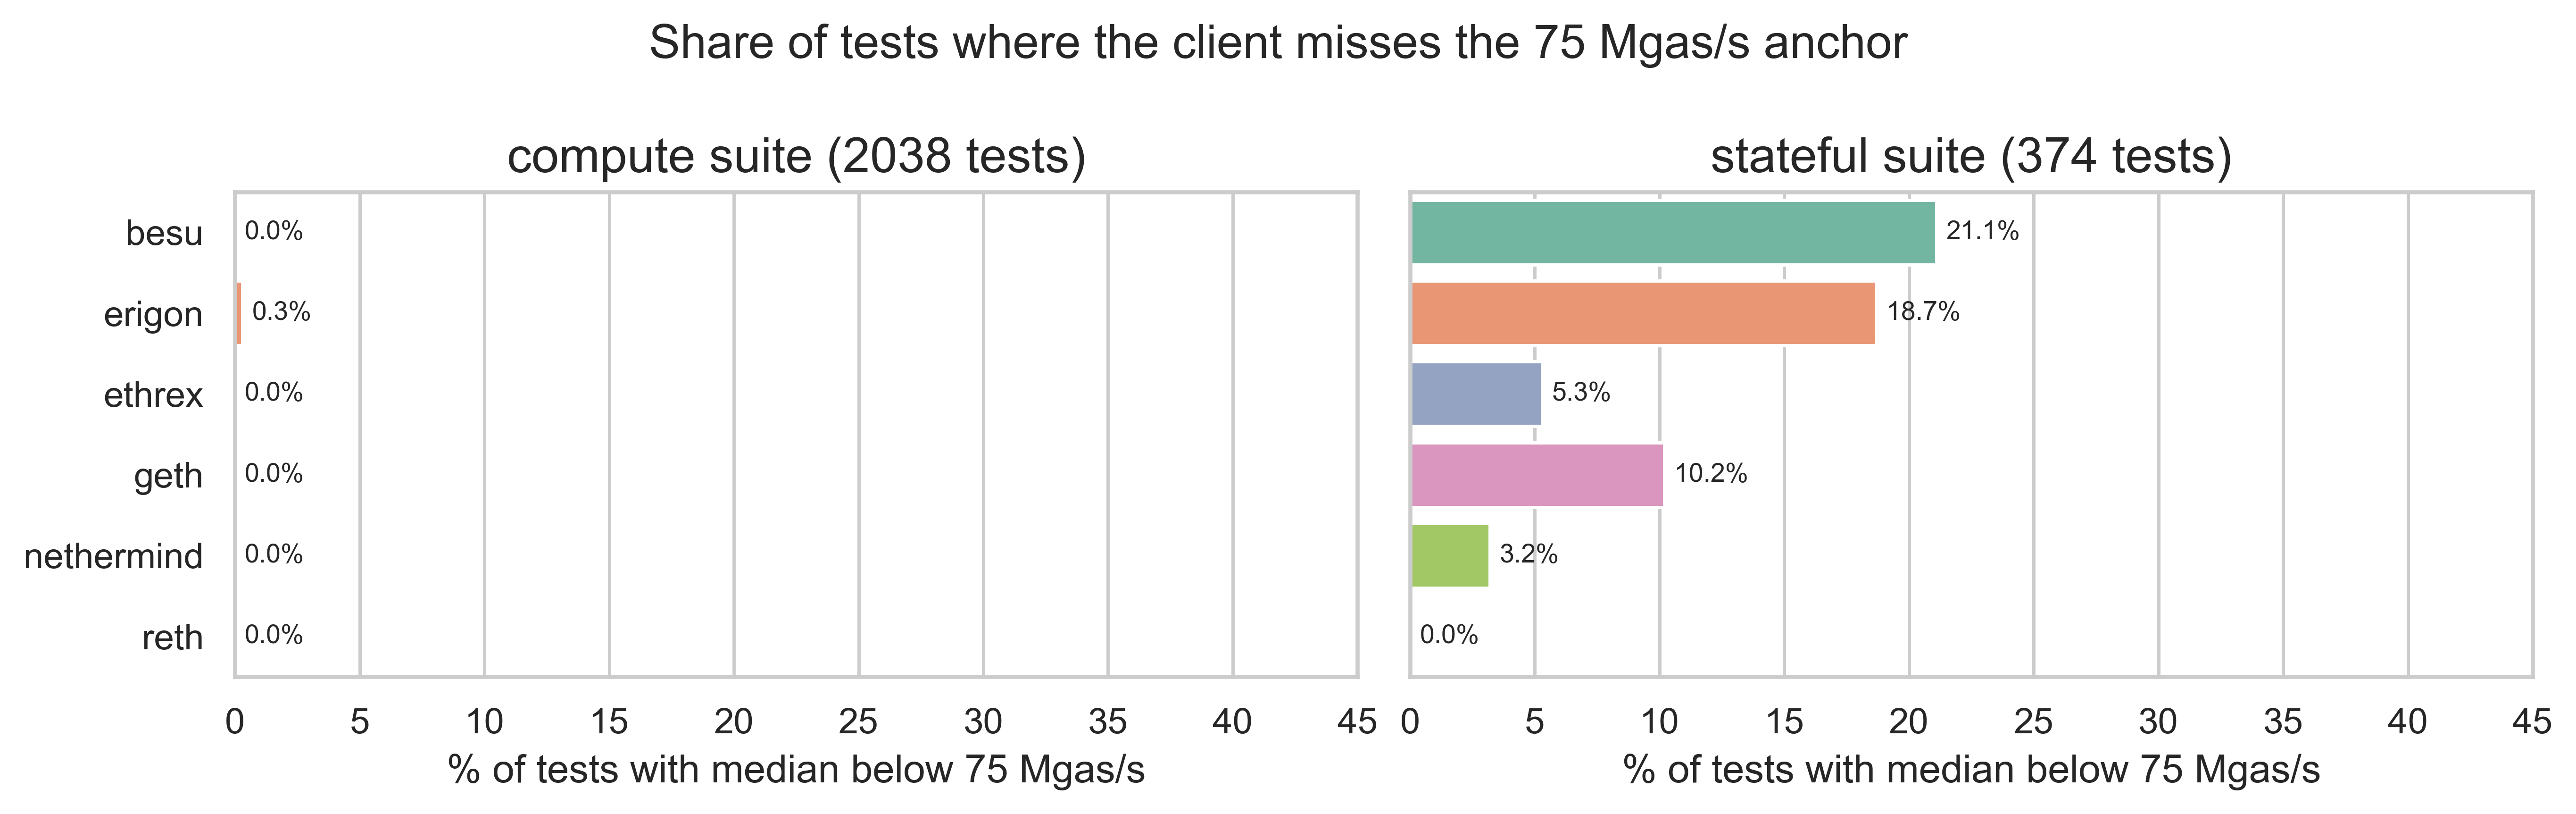

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, suite in zip(axes, SUITES):
    suite_summary = anchor_summary[anchor_summary["suite"] == suite]
    sns.barplot(
        data=suite_summary,
        y="client",
        x="pct_below",
        hue="client",
        order=CLIENT_ORDER,
        legend=False,
        ax=ax,
    )
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)
    n_tests = suite_summary["n_tests"].max()
    ax.set_title(f"{suite} suite ({n_tests} tests)")
    ax.set_xlabel(f"% of tests with median below {ANCHOR_MGAS_S} Mgas/s")
    ax.set_ylabel("")
    ax.set_xlim(0, 45)
plt.suptitle(
    f"Share of tests where the client misses the {ANCHOR_MGAS_S} Mgas/s anchor"
)
plt.tight_layout()
plt.show()

The compute suite is essentially clean — only `erigon` (6 tests) and `ethrex`
(1 test) fall below the anchor out of 2038. The stateful suite is where the
anchor breaks down: `besu` misses it on 21.1% of the 374 non-baseline tests,
`erigon` on 18.7%, `geth` on 10.2%, `ethrex` on 5.3%, `nethermind` on 3.2%, and
`reth` on none.

Worth noting on the compute side: passing is not the same as comfortable.
`besu`'s slowest compute test sits at 92 Mgas/s and `ethrex`'s at 56 Mgas/s
(its one miss), i.e. barely more than the anchor, while `geth`, `nethermind` and
`reth` keep a 1.9–3.1x margin even on their worst compute test.

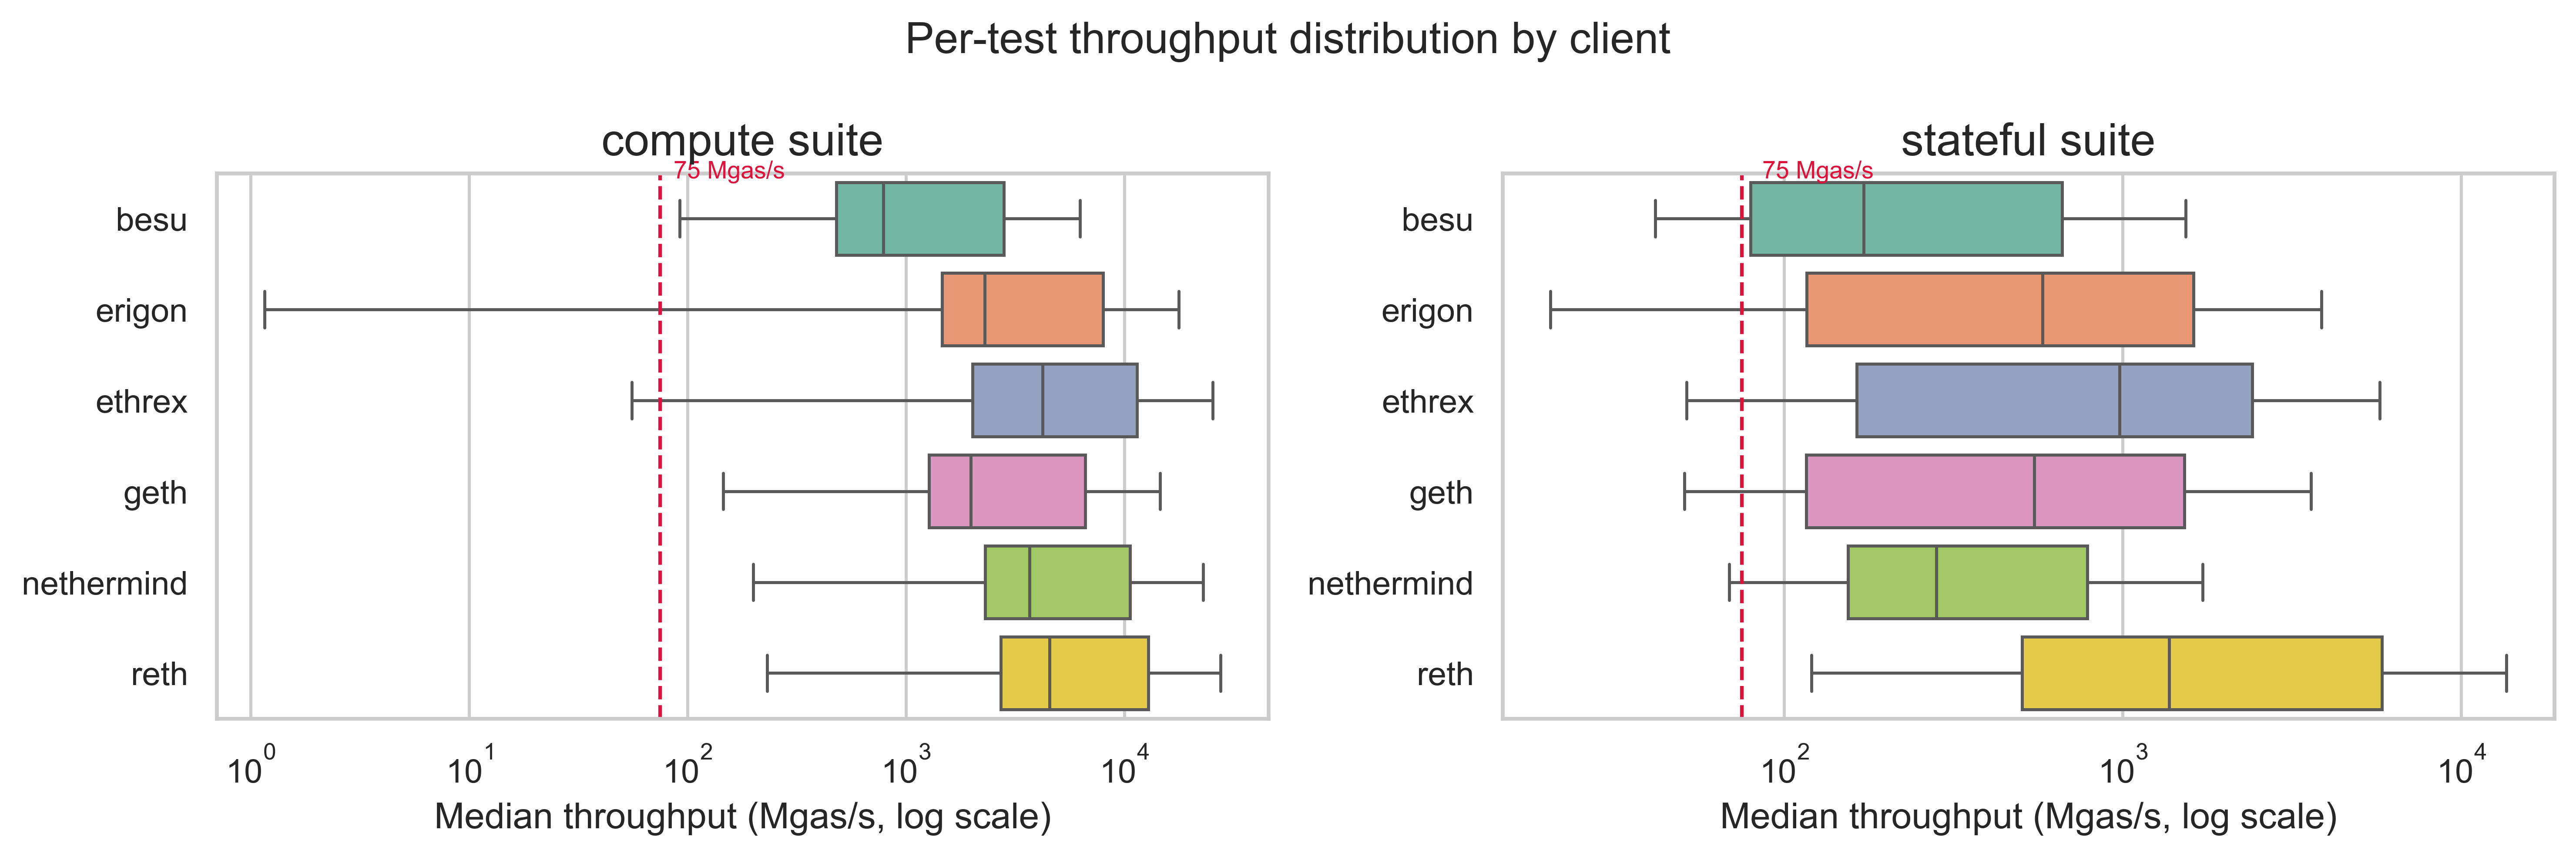

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, suite in zip(axes, SUITES):
    sns.boxplot(
        data=main_df[main_df["suite"] == suite],
        y="client",
        x="median_mgas_s",
        hue="client",
        order=CLIENT_ORDER,
        legend=False,
        showfliers=False,
        ax=ax,
    )
    ax.axvline(ANCHOR_MGAS_S, color="crimson", linestyle="--", linewidth=1.2)
    ax.text(
        ANCHOR_MGAS_S * 1.15,
        -0.45,
        f"{ANCHOR_MGAS_S} Mgas/s",
        color="crimson",
        fontsize=8,
    )
    ax.set_xscale("log")
    ax.set_title(f"{suite} suite")
    ax.set_xlabel("Median throughput (Mgas/s, log scale)")
    ax.set_ylabel("")
plt.suptitle("Per-test throughput distribution by client")
plt.tight_layout()
plt.show()

The medians sit one to two orders of magnitude above the anchor, so the anchor is
not a broad throughput problem — it is a **tail** problem. The plot below zooms
into the bottom of each distribution.

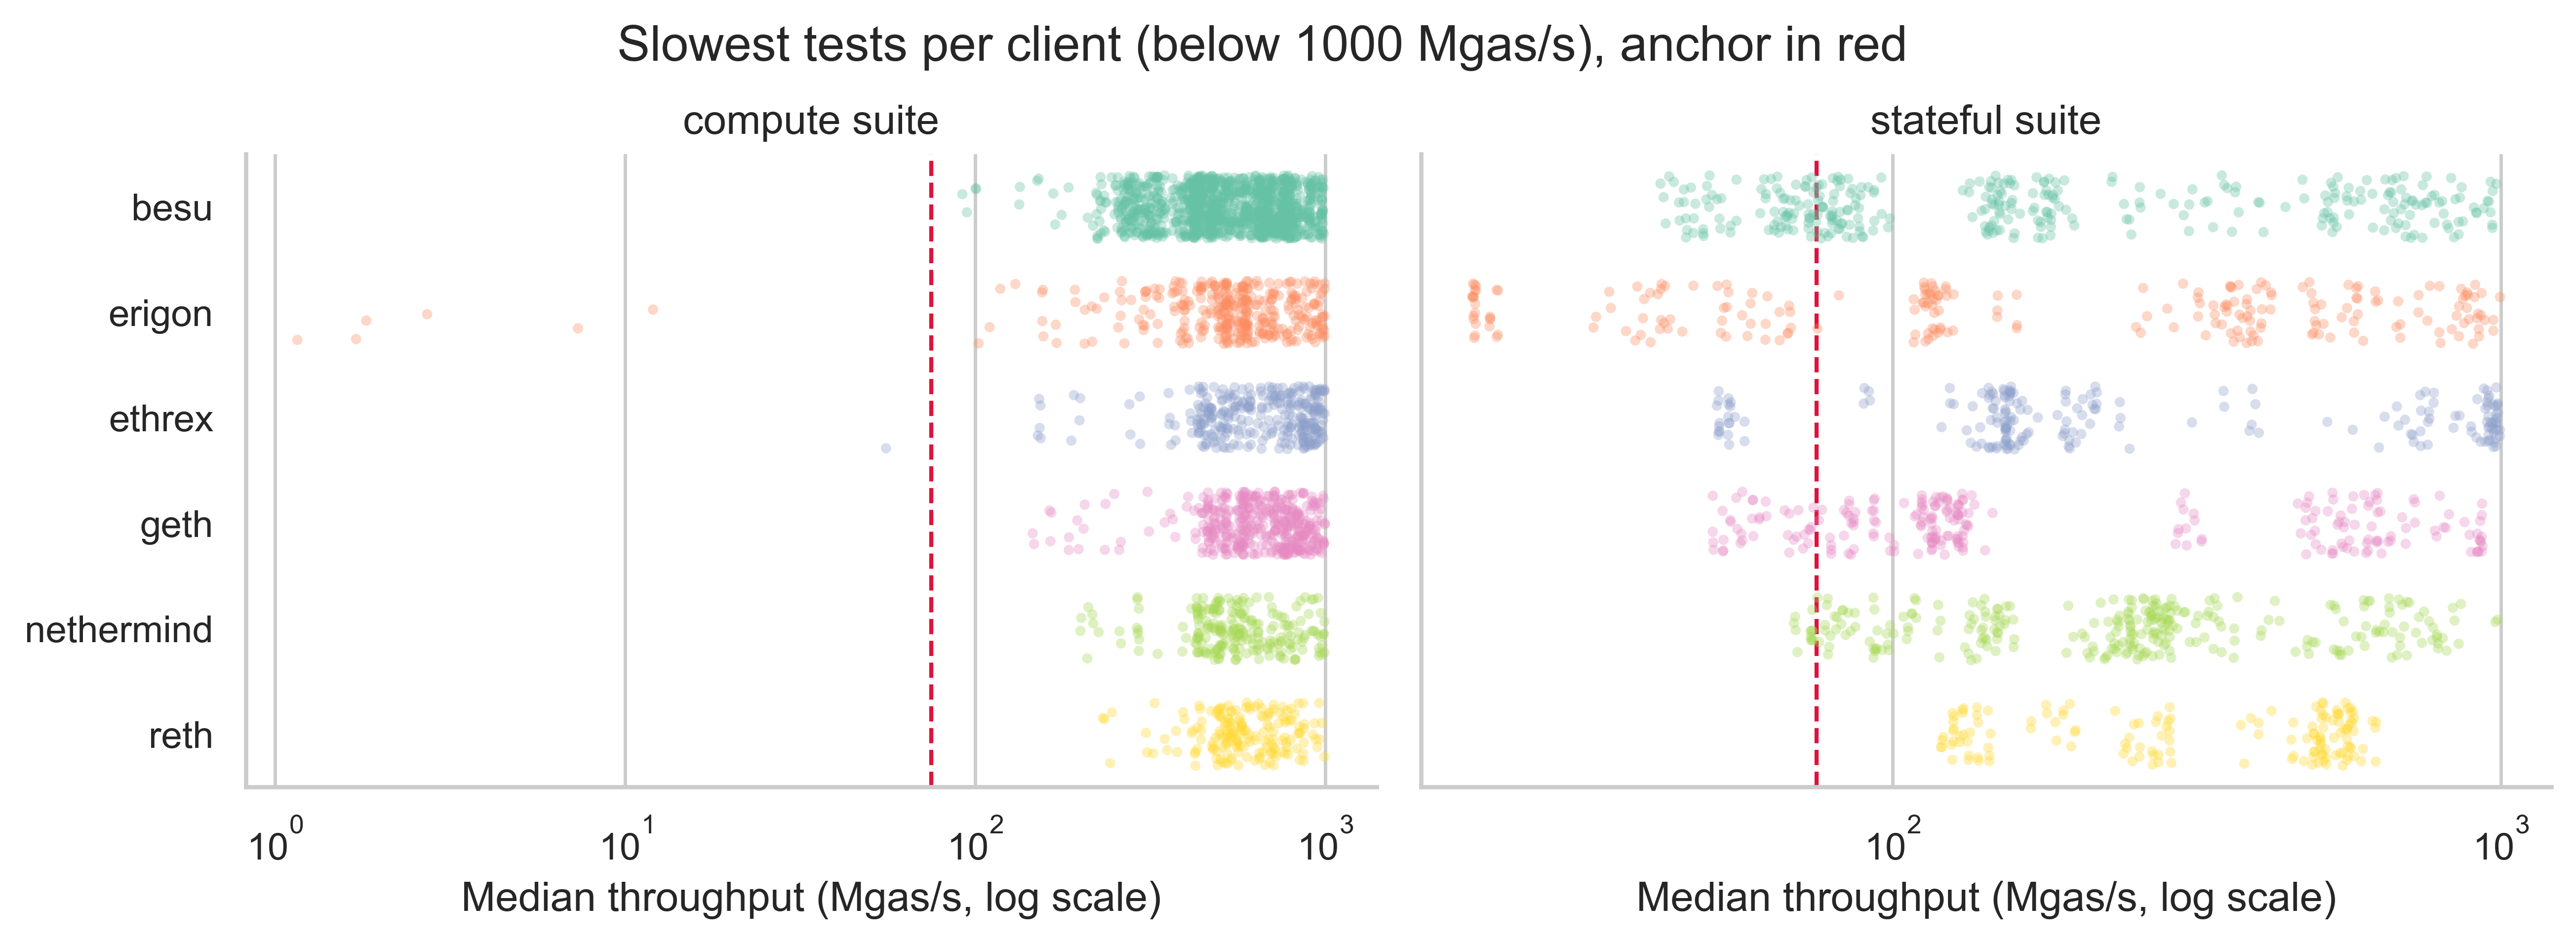

In [16]:
plot_df = main_df[main_df["median_mgas_s"] < 1000]

g = sns.catplot(
    data=plot_df,
    y="client",
    x="median_mgas_s",
    hue="client",
    col="suite",
    order=CLIENT_ORDER,
    kind="strip",
    alpha=0.35,
    size=3,
    jitter=0.3,
    height=3.6,
    aspect=1.5,
    legend=False,
    sharex=False,
)
for ax in g.axes.flat:
    ax.axvline(ANCHOR_MGAS_S, color="crimson", linestyle="--", linewidth=1.2)
    ax.set_xscale("log")
g.set_titles("{col_name} suite")
g.set_xlabels("Median throughput (Mgas/s, log scale)")
g.set_ylabels("")
g.figure.suptitle("Slowest tests per client (below 1000 Mgas/s), anchor in red", y=1.04)
plt.show()

## 4. Where the compute suite misses the anchor

Only 7 (client, test) pairs out of 12,228 fall below the anchor, and they are
concentrated in `erigon`.

In [17]:
compute_below_df = main_df[
    (main_df["suite"] == "compute") & main_df["below_anchor"]
].sort_values("median_mgas_s")

display(
    compute_below_df[
        ["client", "test_func", "test_params", "median_mgas_s", "min_mgas_s", "n_runs"]
    ]
    .assign(
        test_params=lambda d: d["test_params"].str.replace(
            "fork_Amsterdam-blockchain_test_stateful_engine-", "", regex=False
        ),
        median_mgas_s=lambda d: d["median_mgas_s"].round(1),
        min_mgas_s=lambda d: d["min_mgas_s"].round(1),
    )
    .reset_index(drop=True)
)

,client,test_func,test_params,median_mgas_s,min_mgas_s,n_runs
0,erigon,test_ether_transfers,warm_access_False-empty_account-transfer_amoun...,1.2,1.1,94
1,erigon,test_ether_transfers,warm_access_True-empty_account-transfer_amount...,1.7,1.6,94
2,erigon,test_ether_transfers,warm_access_False-empty_account-transfer_amoun...,1.8,1.7,94
3,erigon,test_ether_transfers,warm_access_True-empty_account-transfer_amount...,2.7,2.6,94
4,erigon,test_deploy_then_interact,half_max_txs-single_contract-benchmark-gas-val...,7.3,6.9,94
5,erigon,test_deploy_then_interact,half_max_txs-single_contract-benchmark-gas-val...,12.0,11.7,94
6,ethrex,test_contract_calling_many_addresses,access_warm_False-opcode_CALL-transfer_amount_...,55.6,54.7,26


`erigon` is 28–68x below the anchor on `test_ether_transfers` to **empty
accounts** (1.1–2.7 Mgas/s) and ~6–10x below on `test_deploy_then_interact`
(7–12 Mgas/s). These are pathological outliers rather than marginal misses — no
other client is anywhere near the anchor on the same tests, so this looks like an
`erigon` implementation issue and not a gas-schedule one. `ethrex`'s single miss
(`test_contract_calling_many_addresses`, 56 Mgas/s) is marginal.

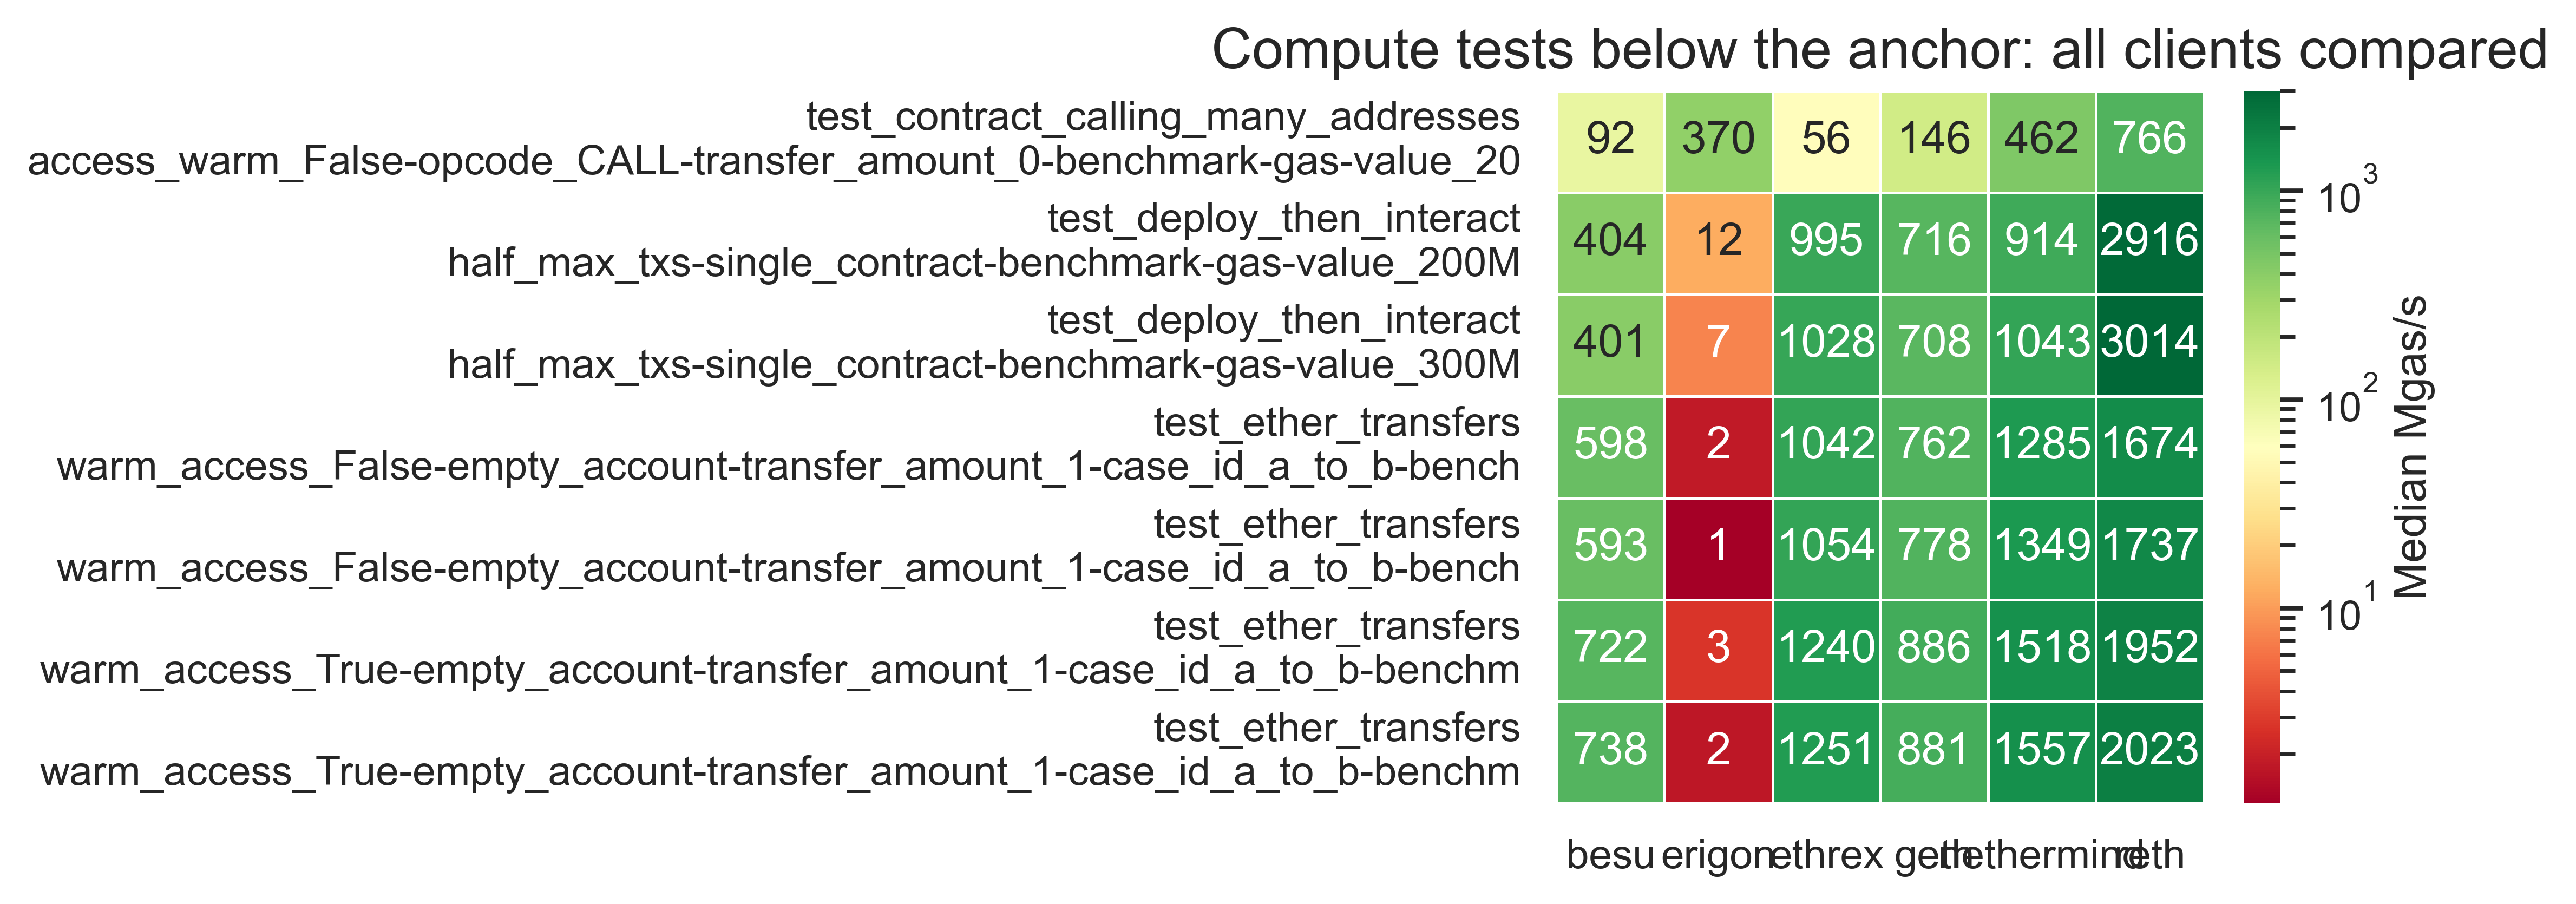

In [18]:
erigon_outlier_tests = compute_below_df["test_name"].unique()
comparison_df = main_df[main_df["test_name"].isin(erigon_outlier_tests)]

pivot = comparison_df.pivot_table(
    index=["test_func", "test_params"], columns="client", values="median_mgas_s"
)
pivot.index = [
    f"{func}\n{params.replace('fork_Amsterdam-blockchain_test_stateful_engine-', '')[:70]}"
    for func, params in pivot.index
]

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(
    pivot[CLIENT_ORDER],
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    norm=plt.matplotlib.colors.LogNorm(),
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Median Mgas/s"},
    ax=ax,
)
ax.set_title(f"Compute tests below the anchor: all clients compared")
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 5. Where the stateful suite misses the anchor

Here the misses are systematic. We break them down by test function.

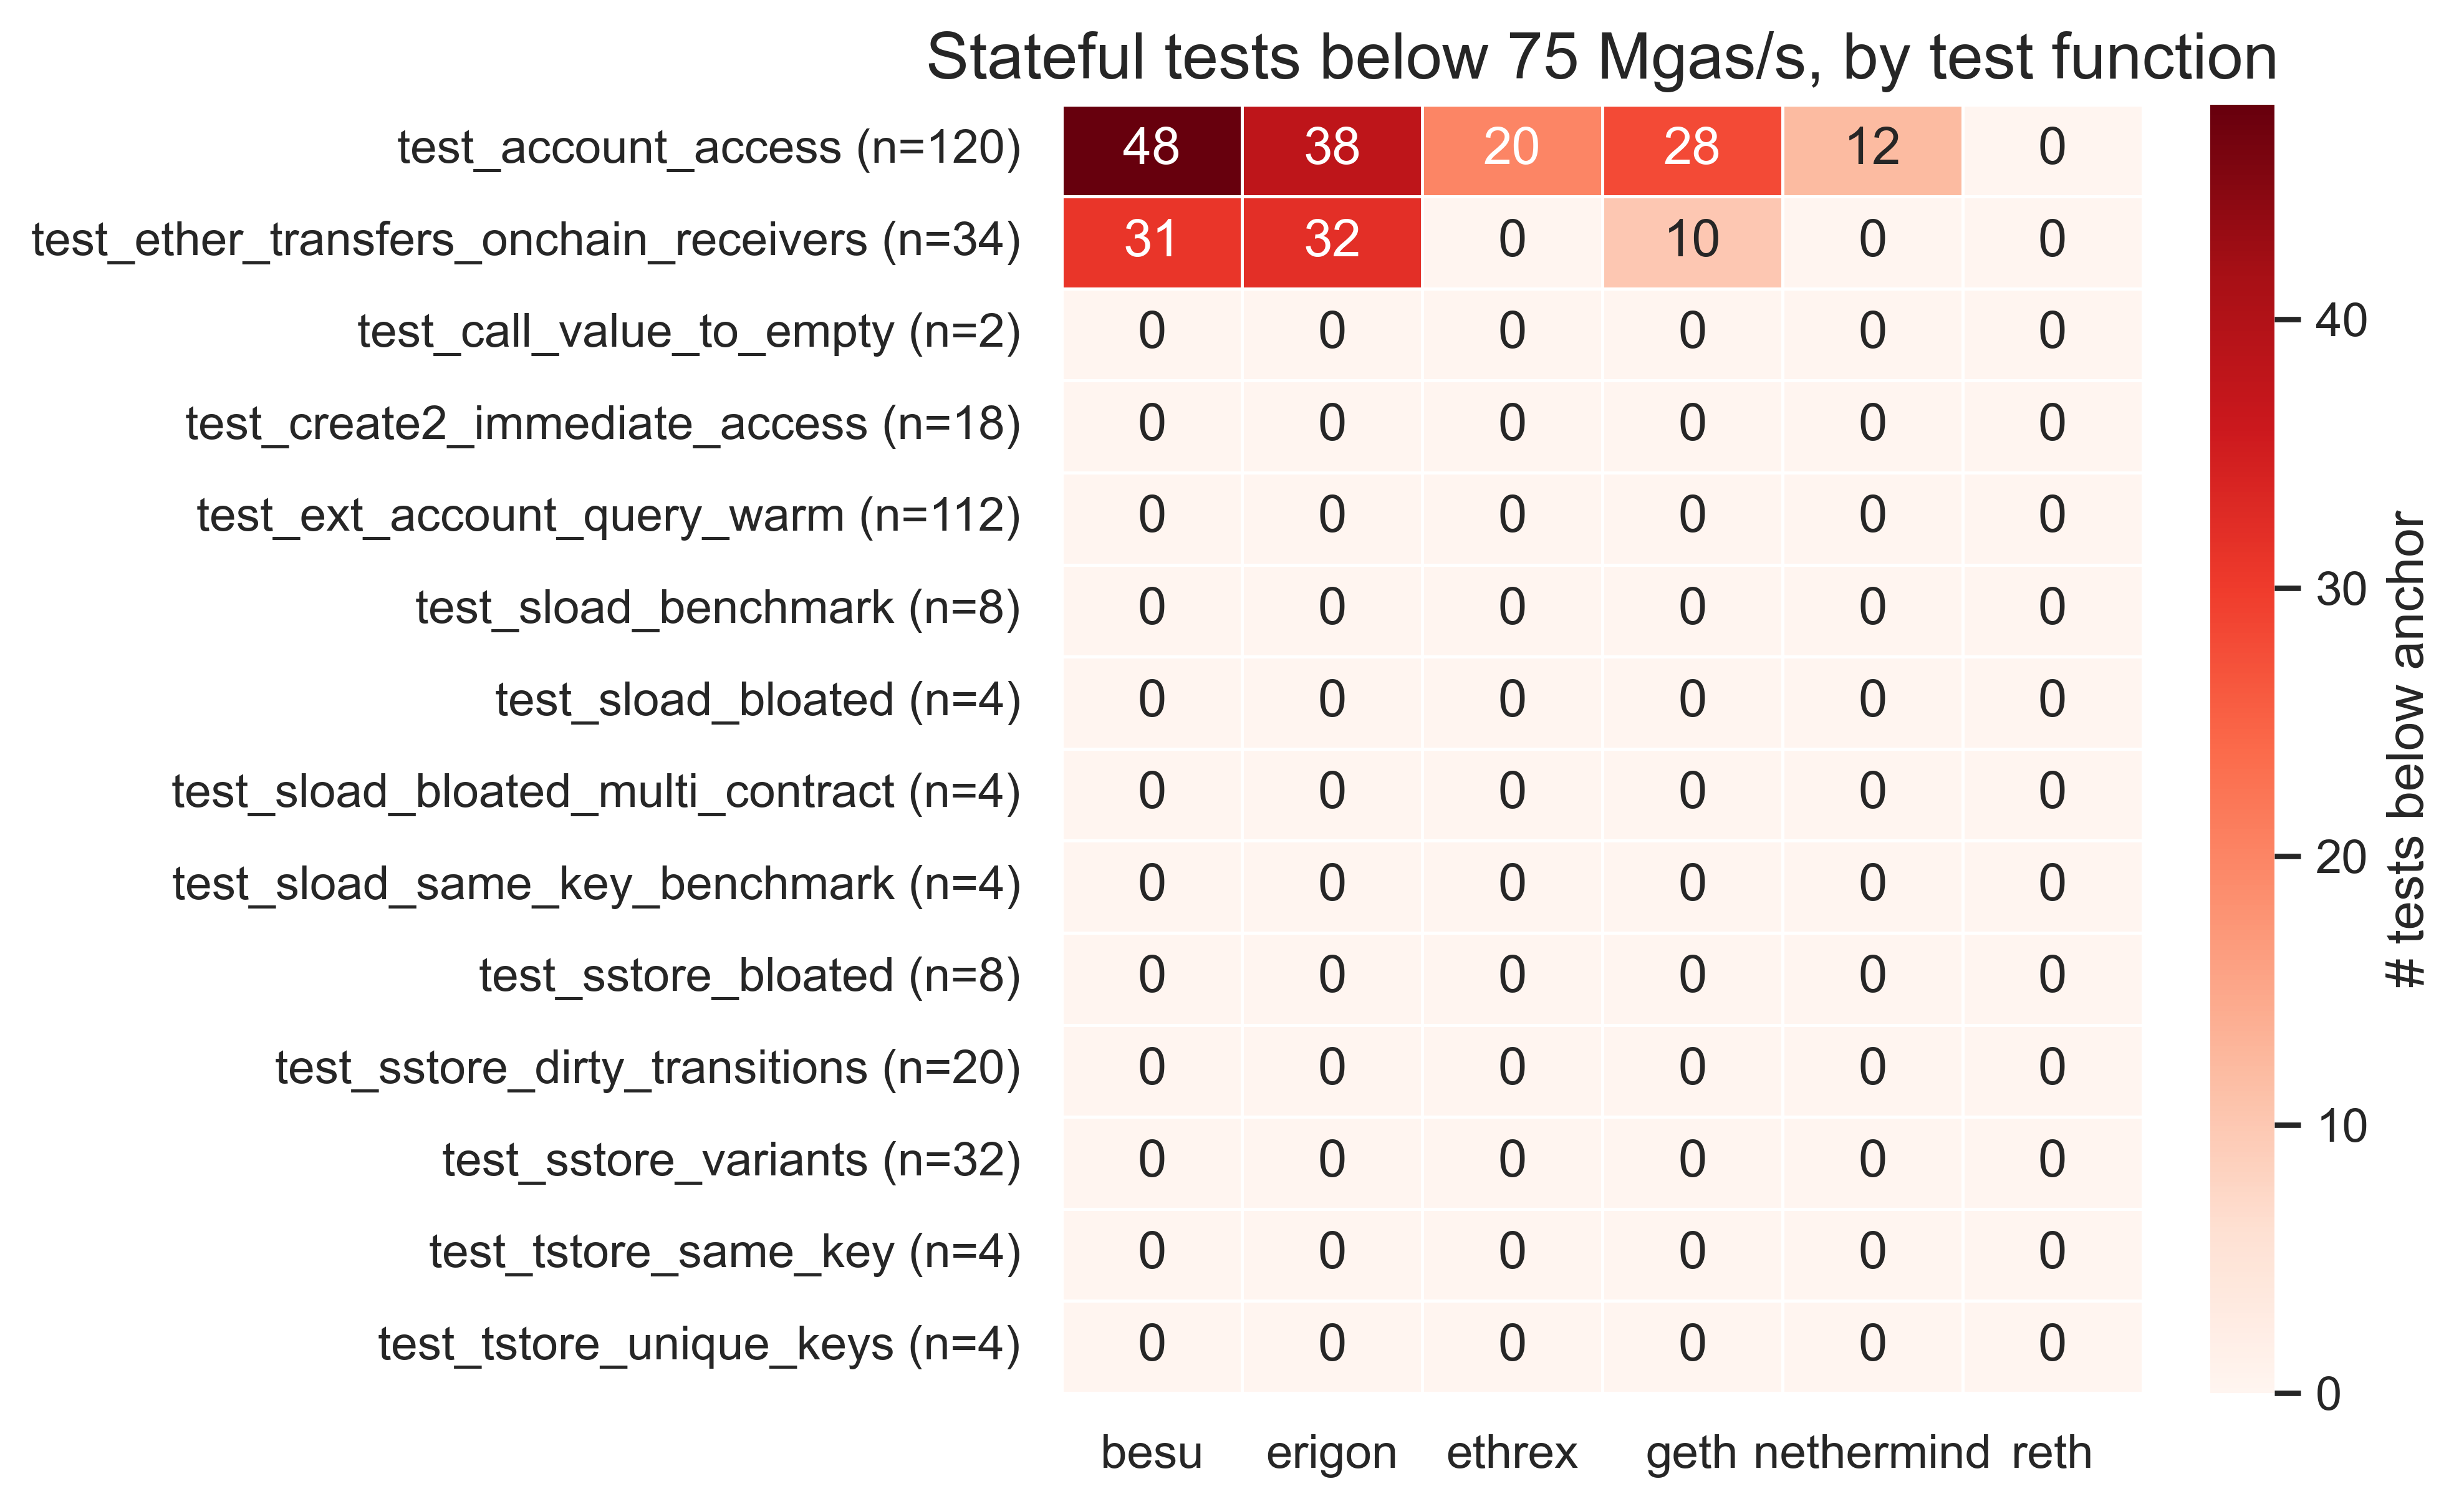

In [19]:
stateful_df = main_df[main_df["suite"] == "stateful"]

func_pivot = stateful_df.pivot_table(
    index="test_func", columns="client", values="below_anchor", aggfunc="sum"
).reindex(columns=CLIENT_ORDER)
func_pivot["n_tests"] = stateful_df.groupby("test_func")["test_name"].nunique()
func_pivot = func_pivot.sort_values(CLIENT_ORDER, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    func_pivot[CLIENT_ORDER],
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "# tests below anchor"},
    ax=ax,
)
ax.set_yticklabels(
    [
        f"{i.get_text()} (n={func_pivot.loc[i.get_text(), 'n_tests']})"
        for i in ax.get_yticklabels()
    ],
    rotation=0,
)
ax.set_title(f"Stateful tests below {ANCHOR_MGAS_S} Mgas/s, by test function")
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

Every stateful shortfall lives in just two test functions —
`test_account_access` and `test_ether_transfers_onchain_receivers`. All the
other storage benchmarks (`sload_*`, `sstore_*`, `tstore_*`,
`ext_account_query_warm`, `create2_immediate_access`) clear the anchor on every
client.

### 5.1 `test_account_access` — cold account access is the bottleneck

This function is parameterised by cache strategy, account mode and opcode.

In [20]:
account_access_df = stateful_df[
    stateful_df["test_func"] == "test_account_access"
].copy()
for param in ["cache_strategy", "account_mode", "opcode", "value_sent"]:
    account_access_df[param] = account_access_df["test_params"].str.extract(
        rf"{param}_([^-]+)"
    )
account_access_df["cache_strategy"] = account_access_df["cache_strategy"].str.replace(
    "CacheStrategy.", "", regex=False
)
account_access_df["account_mode"] = account_access_df["account_mode"].str.replace(
    "AccountMode.", "", regex=False
)

display(
    account_access_df.pivot_table(
        index="cache_strategy",
        columns="client",
        values=["below_anchor", "median_mgas_s"],
        aggfunc={"below_anchor": "sum", "median_mgas_s": "min"},
    ).round(1)
)

below_anchor                                    median_mgas_s  \
client                 besu erigon ethrex geth nethermind reth          besu   
cache_strategy                                                                 
NO_CACHE                 48     38     20   28         12    0          41.6   

                                                      
client         erigon ethrex  geth nethermind   reth  
cache_strategy                                        
NO_CACHE         20.4   51.4  50.7       68.8  120.2

**Every single shortfall is in the `NO_CACHE` strategy.** With `TX` or
`PREVIOUS_BLOCK` caching, all clients stay above the anchor; with cold state
access, five of six clients drop below it.

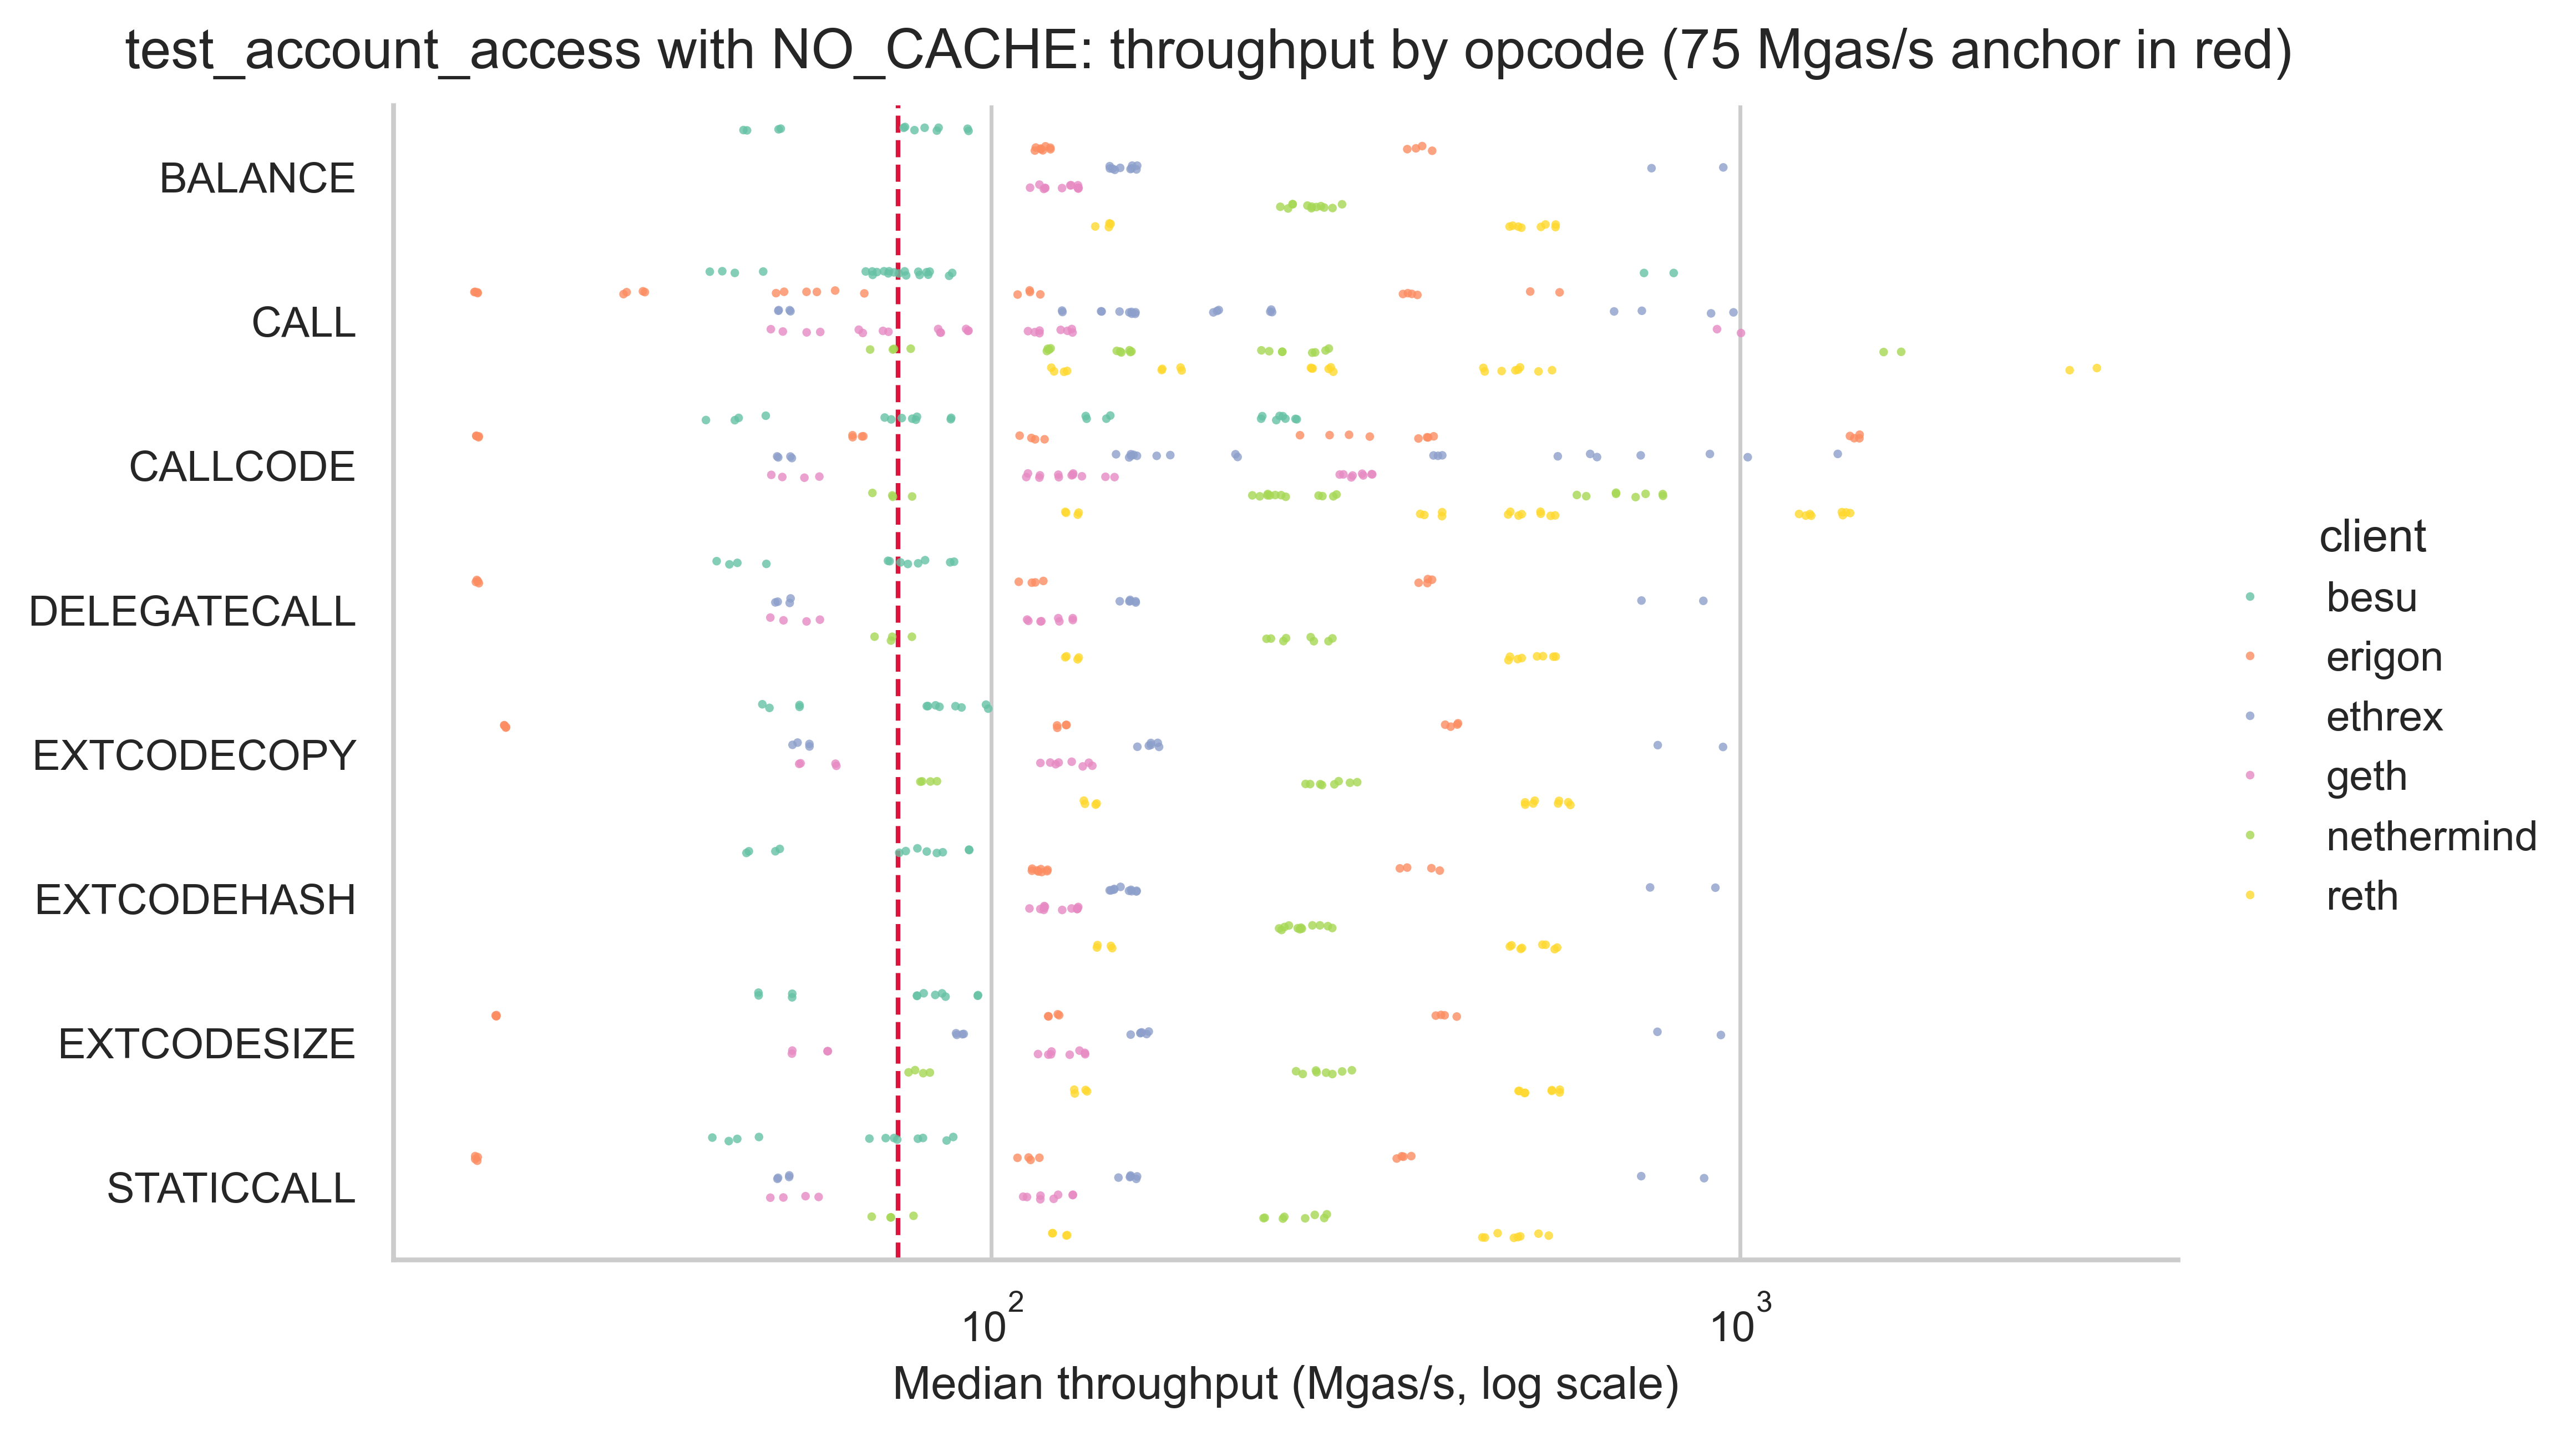

In [21]:
no_cache_df = account_access_df[account_access_df["cache_strategy"] == "NO_CACHE"]

g = sns.catplot(
    data=no_cache_df,
    y="opcode",
    x="median_mgas_s",
    hue="client",
    hue_order=CLIENT_ORDER,
    kind="strip",
    dodge=True,
    height=5,
    aspect=1.7,
    s=5,
    alpha=0.8,
)
for ax in g.axes.flat:
    ax.axvline(ANCHOR_MGAS_S, color="crimson", linestyle="--", linewidth=1.2)
    ax.set_xscale("log")
g.set_xlabels("Median throughput (Mgas/s, log scale)")
g.set_ylabels("")
g.figure.suptitle(
    f"test_account_access with NO_CACHE: throughput by opcode ({ANCHOR_MGAS_S} Mgas/s anchor in red)",
    y=1.02,
)
plt.show()

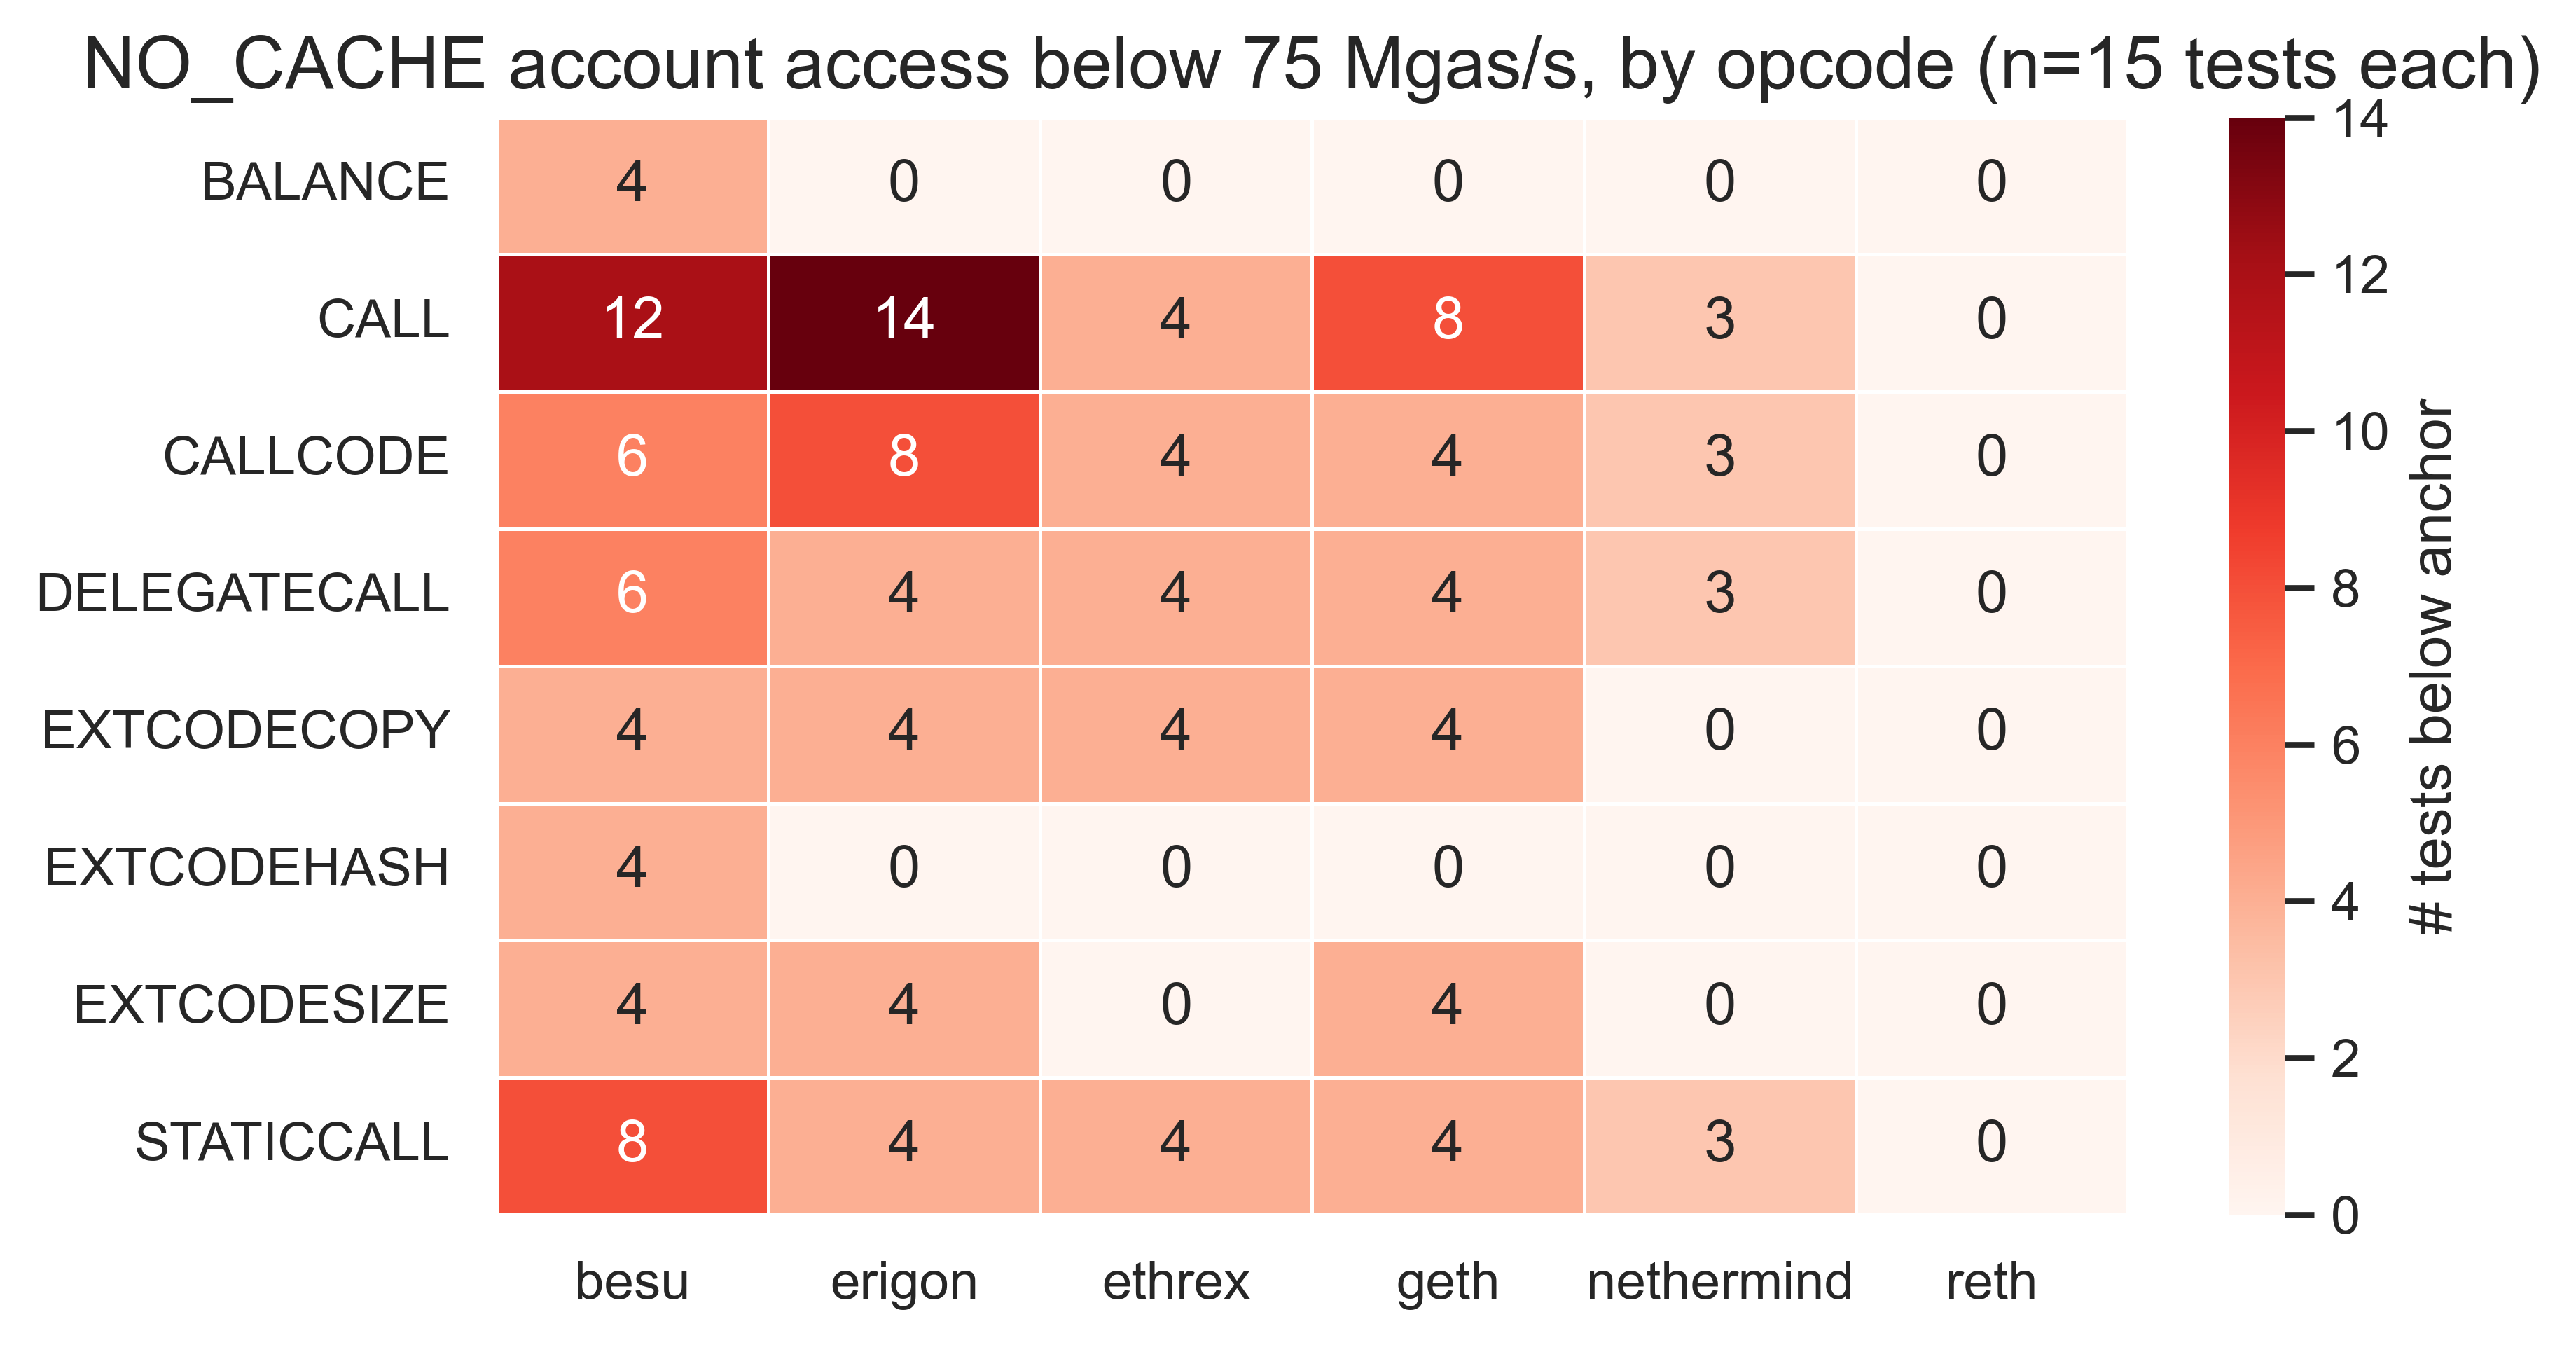

In [22]:
opcode_pivot = no_cache_df.pivot_table(
    index="opcode", columns="client", values="below_anchor", aggfunc="sum"
).reindex(columns=CLIENT_ORDER)
opcode_pivot["n_tests"] = no_cache_df.groupby("opcode")["test_name"].nunique()

fig, ax = plt.subplots(figsize=(7.5, 4))
sns.heatmap(
    opcode_pivot[CLIENT_ORDER],
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "# tests below anchor"},
    ax=ax,
)
ax.set_title(
    f"NO_CACHE account access below {ANCHOR_MGAS_S} Mgas/s, by opcode (n=15 tests each)"
)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [23]:
display(
    no_cache_df.pivot_table(
        index="account_mode", columns="client", values="median_mgas_s", aggfunc="min"
    )
    .reindex(columns=CLIENT_ORDER)
    .round(1)
    .style.background_gradient(cmap="RdYlGn", axis=None)
    .format("{:.1f}")
    .set_caption("Worst median Mgas/s per account mode (NO_CACHE)")
)

client,besu,erigon,ethrex,geth,nethermind,reth
account_mode,,,,,,
EXISTING_CONTRACT_DIFF_MAX,43.7,20.4,51.8,52.6,73.3,120.2
EXISTING_CONTRACT_JUMPDEST,41.6,20.4,51.4,50.7,68.8,120.5
EXISTING_CONTRACT_MINIMAL,76.9,52.8,153.2,85.4,148.6,268.6
EXISTING_CONTRACT_SAME_MAX,76.6,51.6,153.2,85.6,147.0,267.1
EXISTING_EOA,70.3,61.8,146.7,84.9,149.1,267.8
NON_EXISTING_ACCOUNT,67.9,347.8,678.7,110.2,269.5,498.7


The `CALL` family (`CALL`, `CALLCODE`, `DELEGATECALL`, `STATICCALL`) is the
worst affected, and `besu` additionally misses on the pure account-query
opcodes (`BALANCE`, `EXTCODEHASH`). The account modes that hurt most are the
ones forcing a real trie lookup against a large contract
(`EXISTING_CONTRACT_DIFF_MAX`, `EXISTING_CONTRACT_JUMPDEST`).

### 5.2 `test_ether_transfers_onchain_receivers`

,count,min,median,max
client,,,,
besu,34,60.6,66.1,347.7
erigon,34,36.5,44.1,290.0
ethrex,34,120.4,192.7,695.7
geth,34,67.6,83.2,506.8
nethermind,34,75.3,95.2,773.7
reth,30,185.3,251.8,1539.3


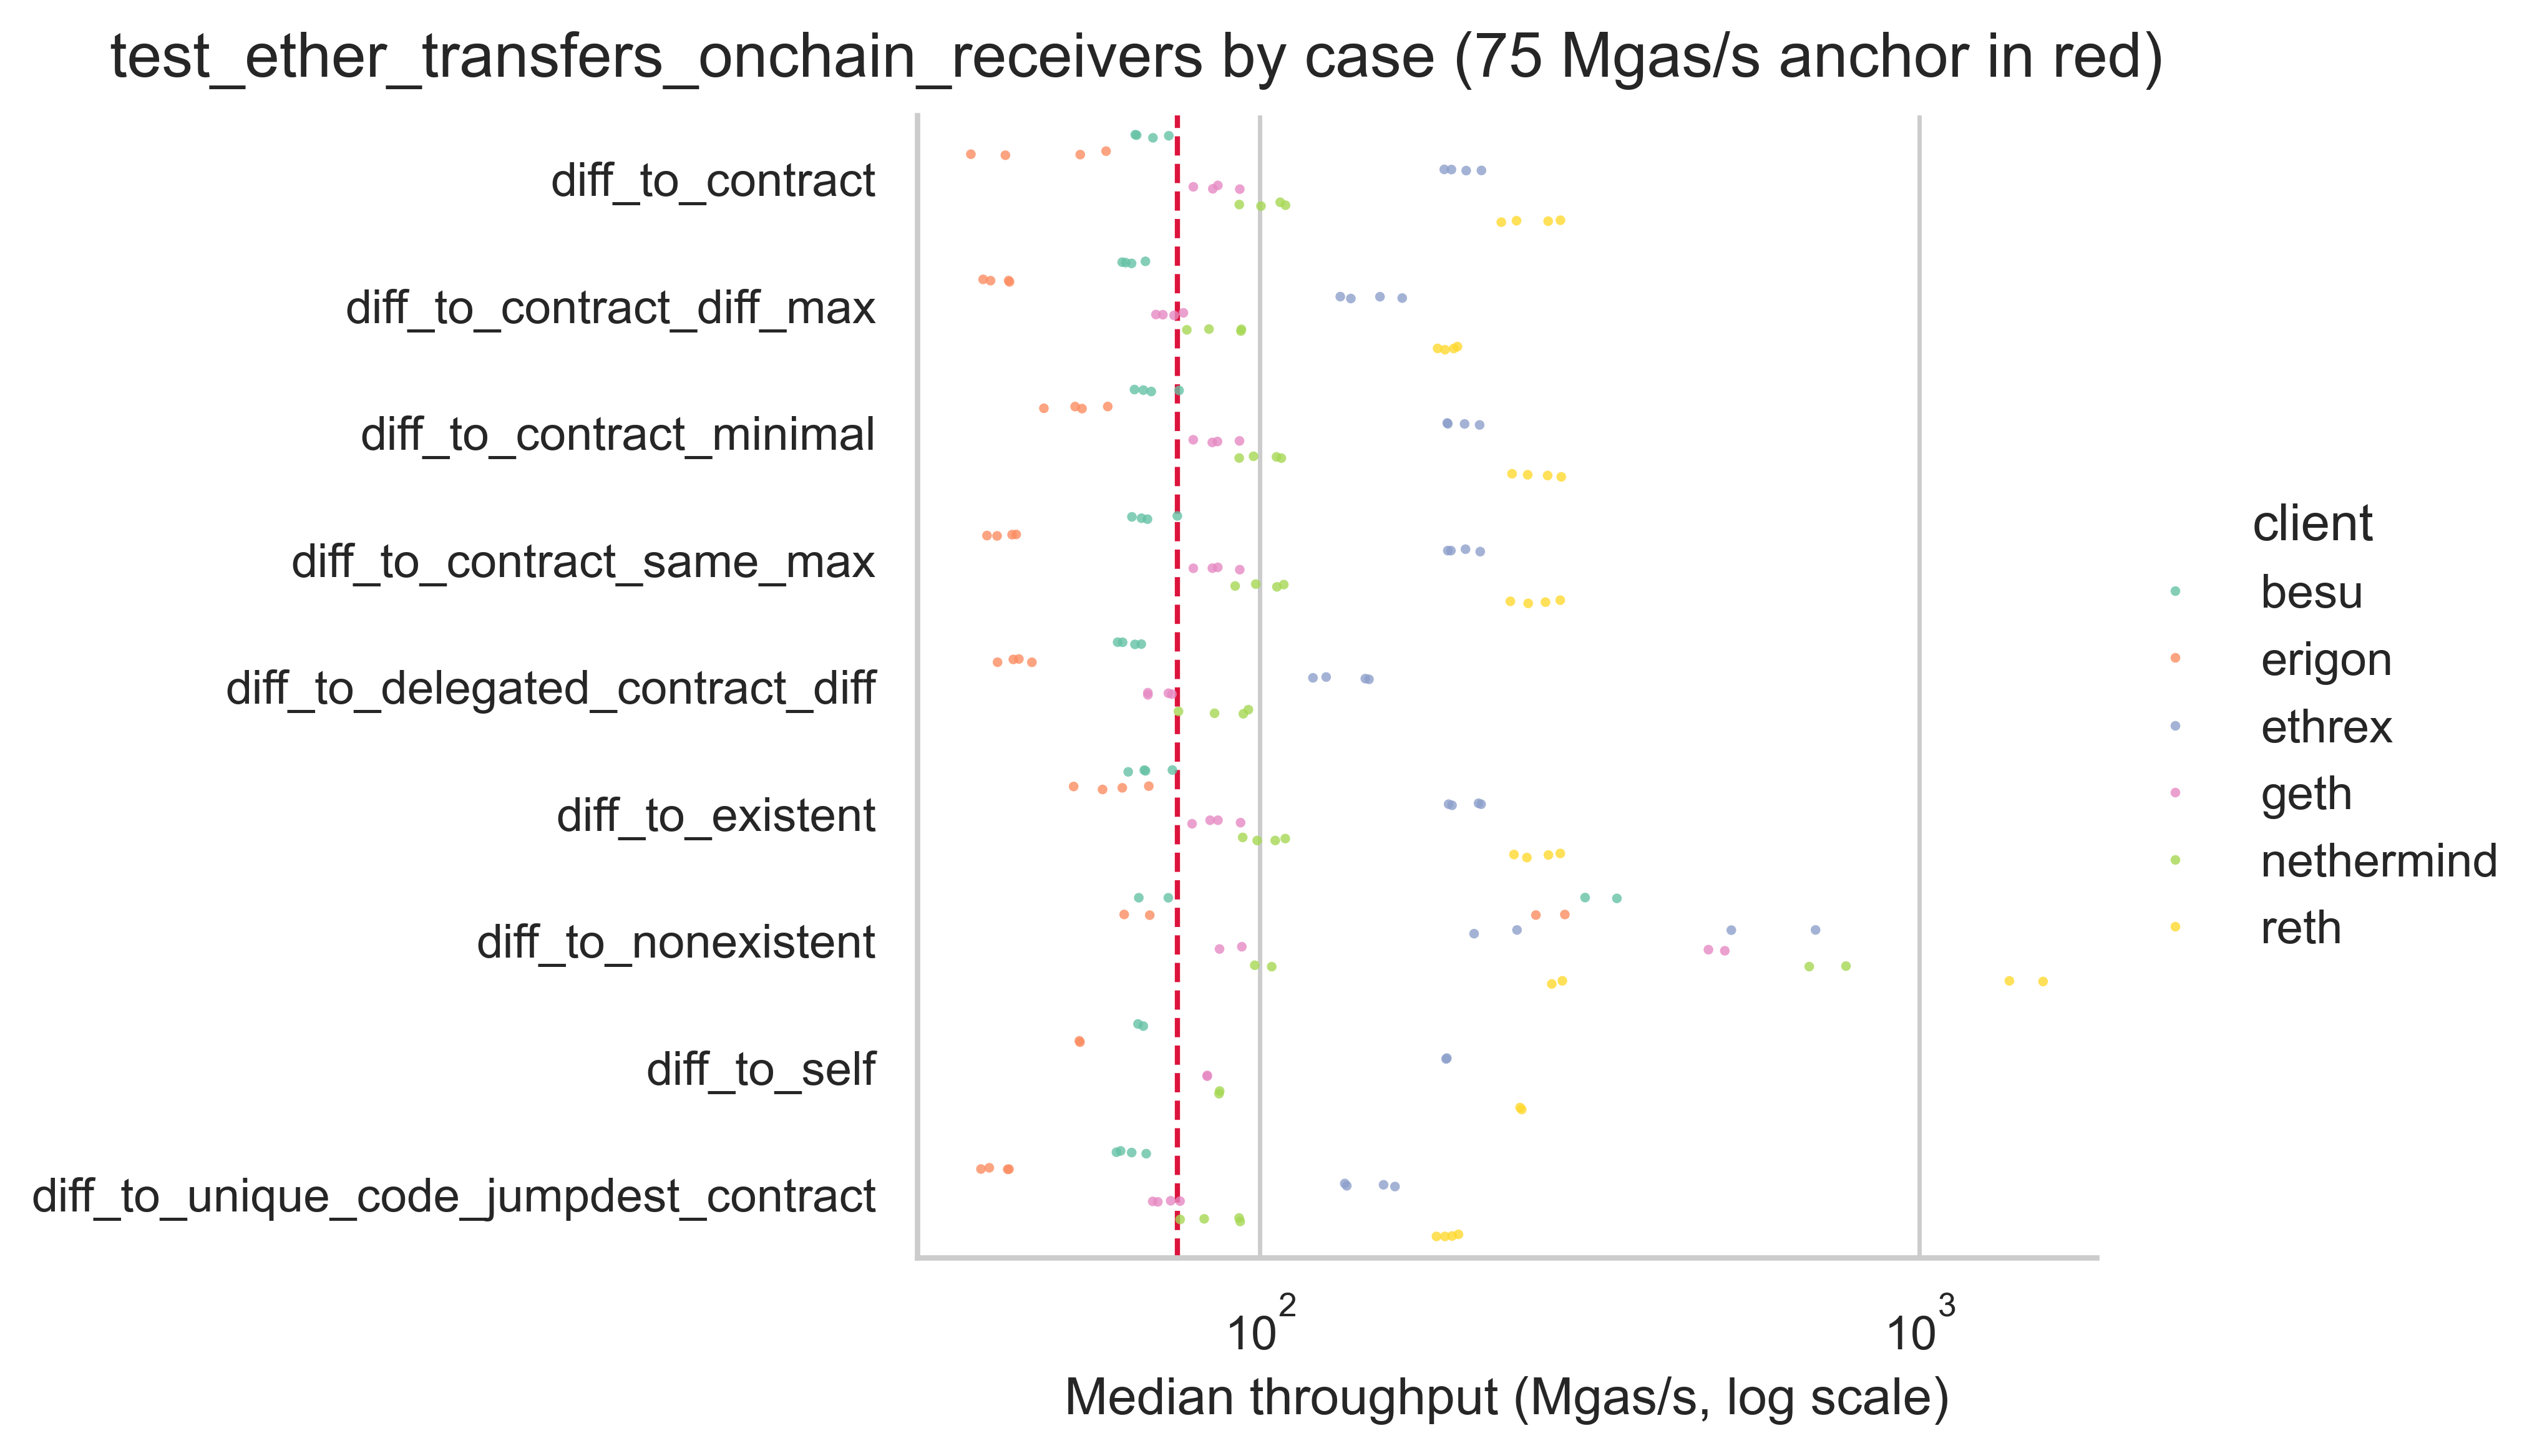

In [24]:
transfers_df = stateful_df[
    stateful_df["test_func"] == "test_ether_transfers_onchain_receivers"
].copy()
transfers_df["case_id"] = transfers_df["test_params"].str.extract(r"case_id_([^-]+)")

display(
    transfers_df.groupby("client")["median_mgas_s"]
    .agg(["count", "min", "median", "max"])
    .round(1)
    .reindex(CLIENT_ORDER)
)

g = sns.catplot(
    data=transfers_df,
    y="case_id",
    x="median_mgas_s",
    hue="client",
    hue_order=CLIENT_ORDER,
    kind="strip",
    dodge=True,
    height=4.5,
    aspect=1.7,
    s=5,
    alpha=0.8,
)
for ax in g.axes.flat:
    ax.axvline(ANCHOR_MGAS_S, color="crimson", linestyle="--", linewidth=1.2)
    ax.set_xscale("log")
g.set_xlabels("Median throughput (Mgas/s, log scale)")
g.set_ylabels("")
g.figure.suptitle(
    f"test_ether_transfers_onchain_receivers by case ({ANCHOR_MGAS_S} Mgas/s anchor in red)",
    y=1.02,
)
plt.show()

`besu` misses the anchor on 31 of these tests (median down to 61 Mgas/s) and
`erigon` on 32 (down to 36), `geth` on 10, while `nethermind` now clears every
case. Unlike the compute outliers these are *marginal* misses spread across
three clients, which points at the gas schedule for on-chain ether transfers
rather than a single implementation.

## 6. Universal vs client-specific shortfalls

If a test is below the anchor for most clients, the gas schedule is the likely
culprit. If it is below for one client only, it is an implementation issue.

In [25]:
per_test_below = (
    main_df.groupby(["suite", "test_func", "test_name"])["below_anchor"]
    .agg(n_clients_below="sum", n_clients="size")
    .reset_index()
)

display(
    per_test_below.groupby(["suite", "n_clients_below"])
    .size()
    .rename("n_tests")
    .to_frame()
)

n_tests
suite    n_clients_below         
compute  0                   2031
         1                      7
stateful 0                    284
         1                     31
         2                     21
         3                     18
         4                      8
         5                     12

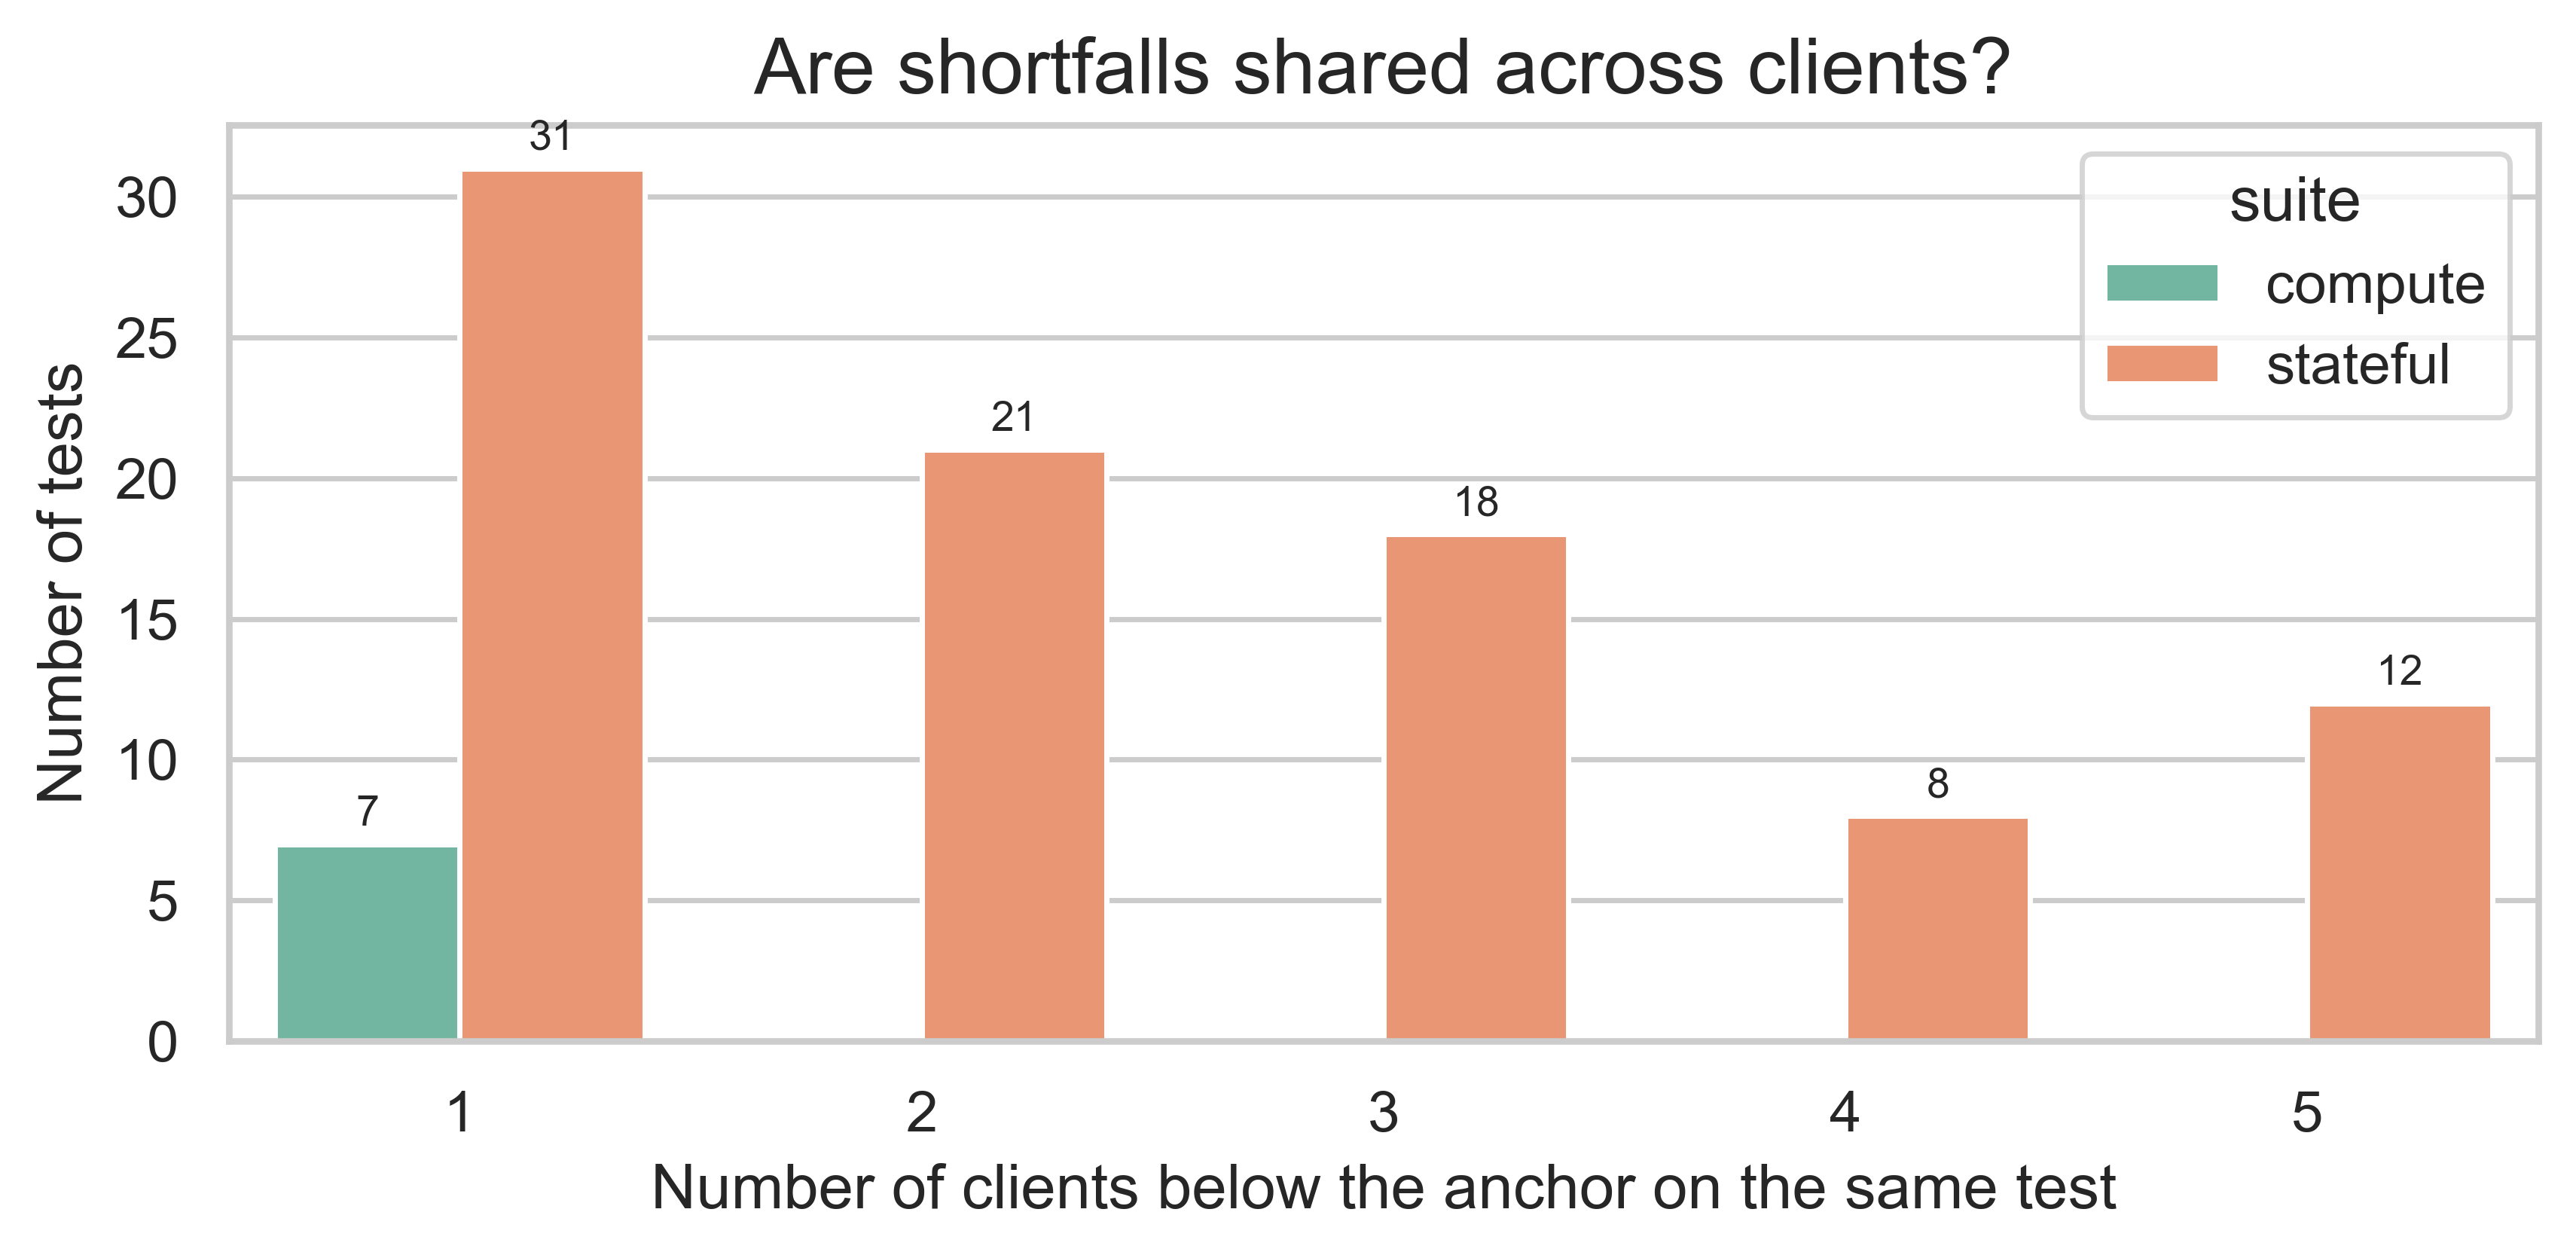

In [26]:
fig, ax = plt.subplots(figsize=(7, 3.5))
count_df = (
    per_test_below[per_test_below["n_clients_below"] > 0]
    .groupby(["suite", "n_clients_below"])
    .size()
    .rename("n_tests")
    .reset_index()
)
sns.barplot(data=count_df, x="n_clients_below", y="n_tests", hue="suite", ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2, fontsize=8)
ax.set_xlabel("Number of clients below the anchor on the same test")
ax.set_ylabel("Number of tests")
ax.set_title("Are shortfalls shared across clients?")
plt.tight_layout()
plt.show()

12 tests are below the anchor for 5+ of the 6 clients:


,n_tests
test_func,
test_account_access,12


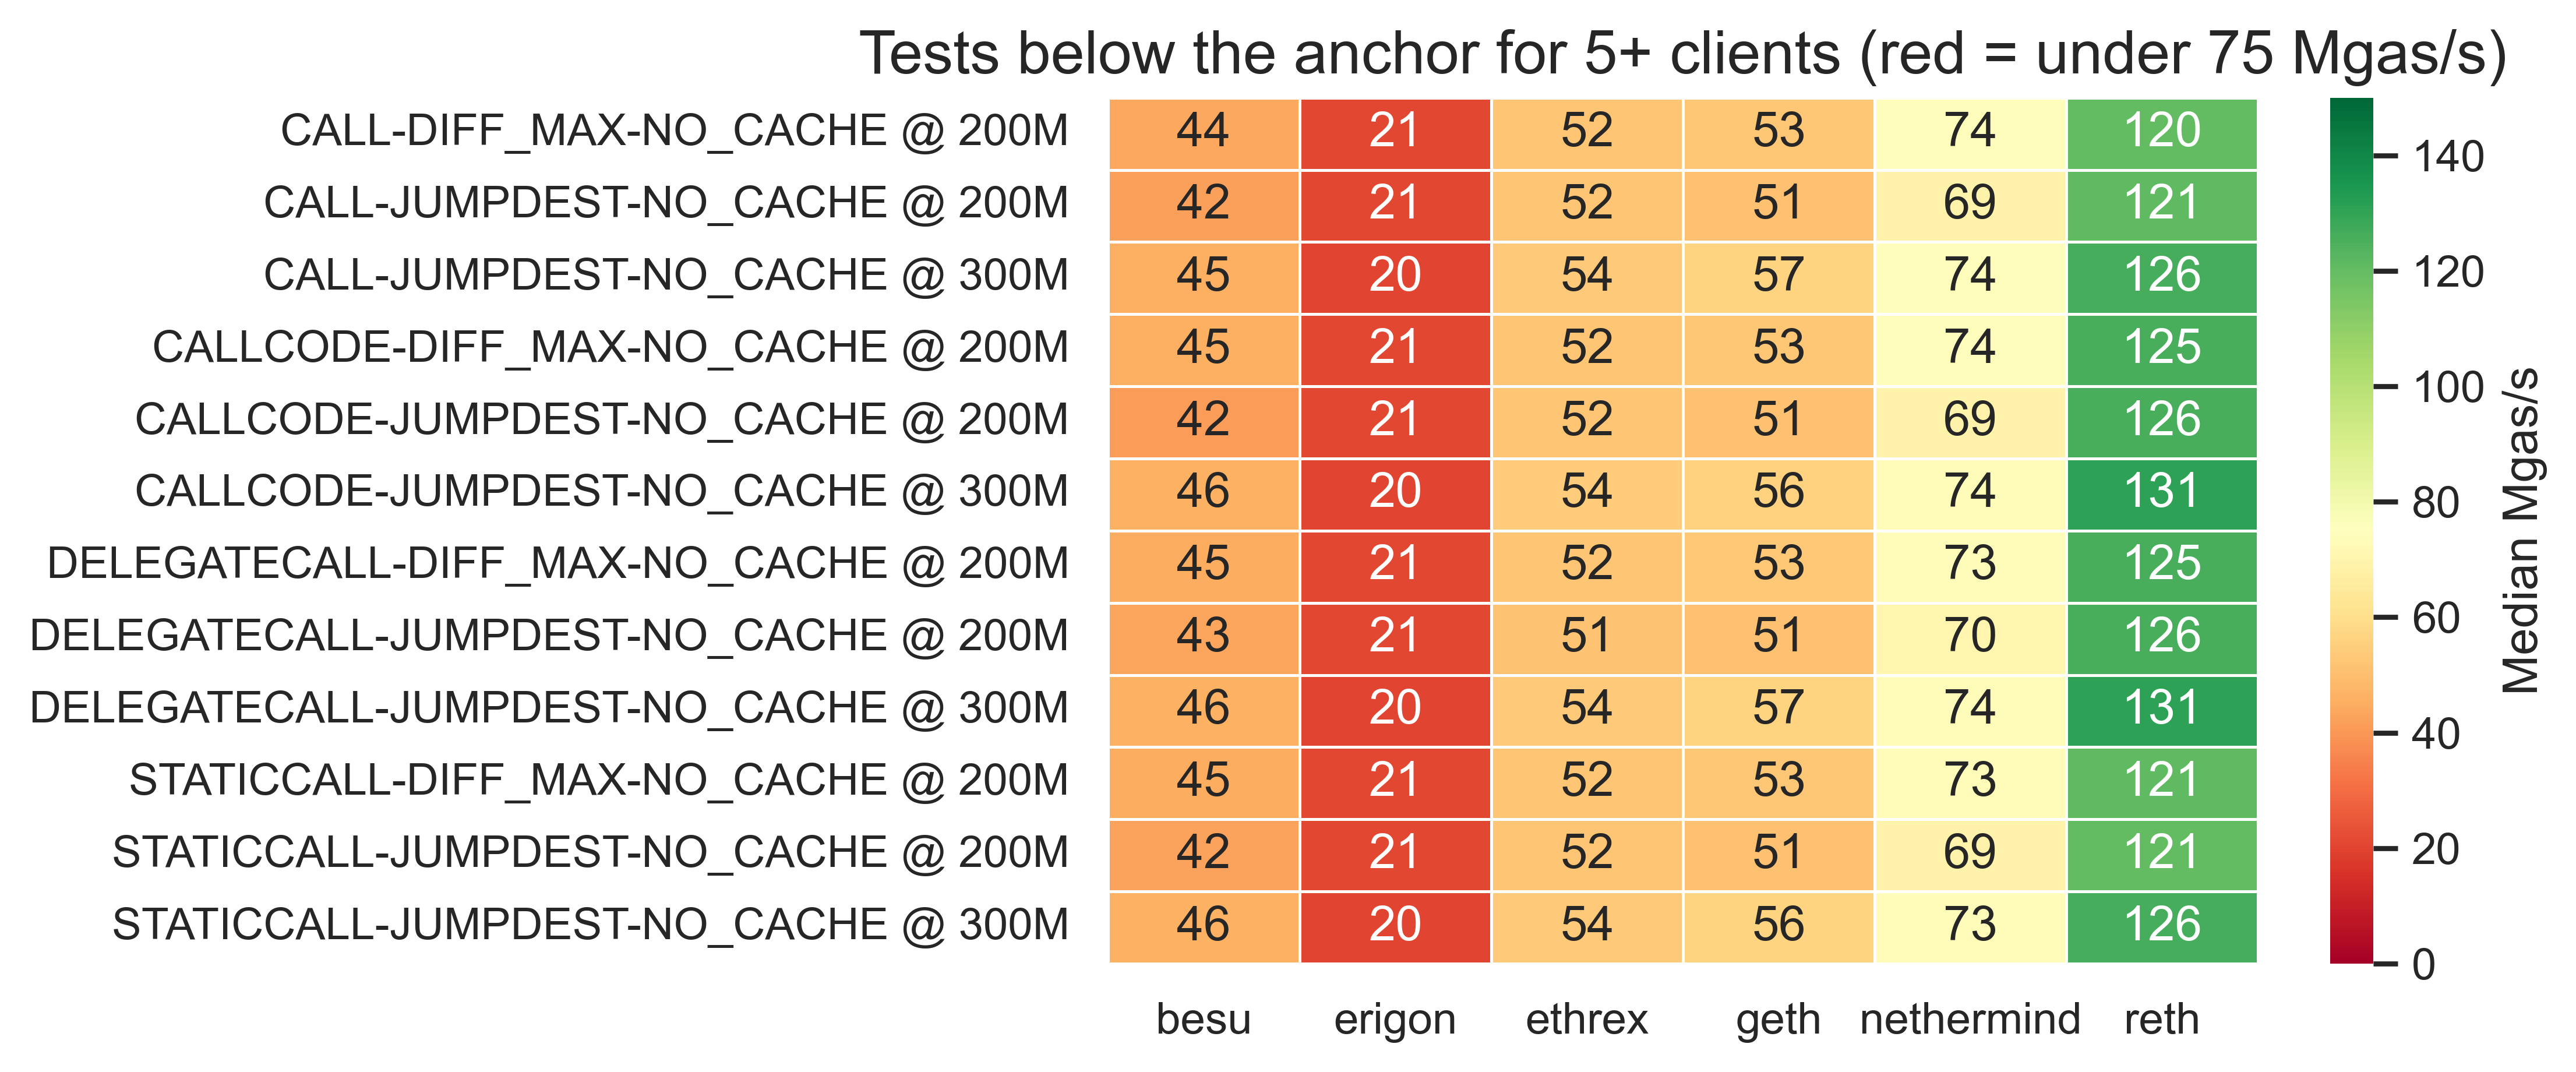

In [27]:
universal_df = per_test_below[per_test_below["n_clients_below"] >= 5]
print(f"{len(universal_df)} tests are below the anchor for 5+ of the 6 clients:")
display(universal_df["test_func"].value_counts().to_frame("n_tests"))

worst_universal = (
    main_df[main_df["test_name"].isin(universal_df["test_name"])]
    .pivot_table(index="test_params", columns="client", values="median_mgas_s")
    .reindex(columns=CLIENT_ORDER)
)
label_replacements = {
    "fork_Amsterdam-blockchain_test_stateful_engine-": "",
    "overhead_baseline_False-": "",
    "cache_strategy_CacheStrategy.NO_CACHE": "NO_CACHE",
    "account_mode_AccountMode.EXISTING_CONTRACT_": "",
    "opcode_": "",
    "value_sent_0-": "",
    "-benchmark-gas-value_": " @ ",
}


def shorten_params(params: str) -> str:
    """Strip the boilerplate shared by every test id so labels stay readable."""
    for old, new in label_replacements.items():
        params = params.replace(old, new)
    return params


worst_universal.index = [shorten_params(i) for i in worst_universal.index]

fig, ax = plt.subplots(figsize=(9, max(3, 0.32 * len(worst_universal))))
sns.heatmap(
    worst_universal,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=ANCHOR_MGAS_S,
    vmin=0,
    vmax=2 * ANCHOR_MGAS_S,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Median Mgas/s"},
    ax=ax,
)
ax.set_title(
    f"Tests below the anchor for 5+ clients (red = under {ANCHOR_MGAS_S} Mgas/s)"
)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 7. Overhead-baseline variants (reported separately)

For completeness: the `overhead_baseline_True` variants are filled to only ~7M
gas, so they are dominated by fixed per-block cost and are **not** a valid
anchor test. `besu` and `nethermind` are below 75 Mgas/s on all 80 of them,
which reflects their per-block overhead rather than execution throughput.

In [28]:
display(
    baseline_df.groupby("client")
    .agg(
        n_tests=("test_name", "size"),
        n_below=("below_anchor", "sum"),
        min_mgas_s=("median_mgas_s", "min"),
        median_mgas_s=("median_mgas_s", "median"),
    )
    .round(1)
    .reindex(CLIENT_ORDER)
)

,n_tests,n_below,min_mgas_s,median_mgas_s
client,,,,
besu,80,80,17.1,33.7
erigon,80,0,144.7,183.3
ethrex,80,0,189.2,256.9
geth,80,0,147.1,170.6
nethermind,80,80,16.6,27.3
reth,80,0,127.0,196.6


## 8. Export the anchor table

In [29]:
export_df = (
    main_df.pivot_table(
        index=["suite", "test_func", "test_params"],
        columns="client",
        values="median_mgas_s",
    )
    .reindex(columns=CLIENT_ORDER)
    .round(1)
)
export_df["n_clients_below_anchor"] = (export_df[CLIENT_ORDER] < ANCHOR_MGAS_S).sum(
    axis=1
)
export_df = export_df.sort_values("n_clients_below_anchor", ascending=False)

export_path = os.path.join(
    repo_dir, "data", "median_mgas_s_by_test_and_client_2026-08-13.csv"
)
export_df.to_csv(export_path)
print(f"Wrote {len(export_df)} rows to {os.path.relpath(export_path, repo_dir)}")
display(export_df.head(10))

Wrote 2412 rows to data/median_mgas_s_by_test_and_client_2026-08-13.csv


client                                                                           besu  \
suite    test_func           test_params                                                
stateful test_account_access fork_Amsterdam-blockchain_test_stateful_engine-...  45.8   
                             fork_Amsterdam-blockchain_test_stateful_engine-...  45.4   
                             fork_Amsterdam-blockchain_test_stateful_engine-...  42.9   
                             fork_Amsterdam-blockchain_test_stateful_engine-...  44.7   
                             fork_Amsterdam-blockchain_test_stateful_engine-...  46.0   
                             fork_Amsterdam-blockchain_test_stateful_engine-...  45.4   
                             fork_Amsterdam-blockchain_test_stateful_engine-...  44.6   
                             fork_Amsterdam-blockchain_test_stateful_engine-...  42.4   
                             fork_Amsterdam-blockchain_test_stateful_engine-...  45.8   
                             fork_Amsterdam-blockchain_test_stateful_engine-...  41.6   

client                                                                           erigon  \
suite    test_func           test_params                                                  
stateful test_account_access fork_Amsterdam-blockchain_test_stateful_engine-...    20.5   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    20.4   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    20.6   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    20.7   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    20.5   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    20.7   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    20.6   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    20.6   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    20.4   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    20.6   

client                                                                           ethrex  \
suite    test_func           test_params                                                  
stateful test_account_access fork_Amsterdam-blockchain_test_stateful_engine-...    53.8   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    53.8   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    51.4   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    51.8   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    54.1   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    51.9   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    51.9   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    51.8   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    53.7   
                             fork_Amsterdam-blockchain_test_stateful_engine-...    51.7   

client                                                                           geth  \
suite    test_func           test_params                                                
stateful test_account_access fork_Amsterdam-blockchain_test_stateful_engine-...  56.6   
                             fork_Amsterdam-blockchain_test_stateful_engine-...  56.6   
                             fork_Amsterdam-blockchain_test_stateful_engine-...  50.7   
                             fork_Amsterdam-blockchain_test_stateful_engine-...  52.7   
                             fork_Amsterdam-blockchain_test_stateful_engine-...  56.2   
                             fork_Amsterdam-blockchain_test_stateful_engine-...  52.6   
                             fork

## Summary

**Data.** 1,720,394 per-test throughput measurements from benchmarkoor for the
`glamsterdam-devnet-7` compute (`9dbe0f5f4ea081b8`, 2038 usable tests) and
stateful (`0c5715e398c47aa3`, 454 tests) suites, covering 6 clients over
2026-07-31 → 2026-08-12. Throughput is the per-test median across runs;
`overhead_baseline_True` variants (~7M gas) are excluded from the anchor check.

**Does everyone clear 75 Mgas/s?** No. Only **reth** clears it on every test.

| Client | Compute below anchor (of 2038) | Stateful below anchor (of 374) | Slowest test (Mgas/s) |
| --- | --- | --- | --- |
| reth | 0 | 0 | 120.2 |
| nethermind | 0 | 12 (3.2%) | 68.8 |
| ethrex | 1 | 20 (5.3%) | 51.4 |
| geth | 0 | 38 (10.2%) | 50.7 |
| erigon | 6 | 70 (18.7%) | 1.2 |
| besu | 0 | 79 (21.1%) | 41.6 |

**Where the anchor breaks.**

1. **Cold account access is the dominant gap.** Every `test_account_access`
   shortfall is in the `NO_CACHE` cache strategy — 5 of 6 clients drop below
   75 Mgas/s there, while `TX` and `PREVIOUS_BLOCK` caching clears it
   everywhere. The `CALL` family is worst hit, and the damage concentrates in
   account modes that force a real trie lookup against a large contract
   (`EXISTING_CONTRACT_DIFF_MAX`, `EXISTING_CONTRACT_JUMPDEST`).
2. **On-chain ether transfers are marginal for three clients.**
   `test_ether_transfers_onchain_receivers` puts `besu` (31 tests, down to
   61 Mgas/s) and `erigon` (32 tests, down to 36) below the anchor, `geth` on
   10, while `nethermind` now clears every case.
3. **`erigon` has two pathological compute cases.** `test_ether_transfers` to
   empty accounts runs at **1.1–2.7 Mgas/s** (28–68x below the anchor) and
   `test_deploy_then_interact` at 7-12 Mgas/s. No other client is remotely
   close to failing these, so this is an `erigon` implementation problem, not a
   pricing one.
4. **Everything else is comfortable.** All storage benchmarks (`sload_*`,
   `sstore_*`, `tstore_*`), warm account queries and `create2_immediate_access`
   clear the anchor on all clients, and 2031 of 2038 compute tests clear it for
   every client. Median throughput sits 10–50x above the anchor, so this is a
   tail problem, not a general throughput problem.

**Shared vs client-specific.** In the stateful suite, 20 tests are below the
anchor for 4+ clients (all cold `test_account_access`) — those are pricing
signals. 31 tests fail for exactly one client — those are implementation
signals.

**Caveats.** Run counts are very uneven (26 runs for `ethrex` vs ~220-230 for
`geth`/`nethermind`), so single-client results on few repetitions are noisier.
`nethermind` runs `master`, and `besu` spans three different pinned images
(`3013b7a`, `aot-3013b7a`, `caa5abf`) across its runs, while the other clients
run a single pinned `glamsterdam-devnet-7` image. `reth`'s clean sweep is over
4 fewer stateful tests, because it *fails* the 4 `diff_to_delegated_contract`
`ether_transfers_onchain_receivers` cases in every run (340 failures over 85
runs) rather than running them slowly — worth resolving before treating `reth`
as fully anchor-compliant.